# Research question: Did the COVID-19 pandemic introduce lasting shifts in narrative?

## Importing and preparing the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')   # authorize once

Mounted at /content/drive


In [ ]:
import pandas as pd
path = '/content/drive/MyDrive/Keyword-analysis'
yt = pd.read_csv(f"{path}/clean_YouTube.csv")

In [ ]:
yt.columns

Index(['source', 'video_id', 'video_url', 'title', 'description', 'date',
       'channel', 'comments', 'views', 'likes', 'comments_count', 'keywords',
       'country', 'year', 'likes_missing', 'topic_num', 'text', 'text_clean'],
      dtype='object')

In [ ]:
import pandas as pd
path = '/content/drive/MyDrive/Keyword-analysis'
pm = pd.read_csv(f"{path}/clean_PubMed.csv")
nw = pd.read_csv(f"{path}/clean_News.csv")
rd = pd.read_csv(f"{path}/clean_Reddit.csv")
yt = pd.read_csv(f"{path}/clean_YouTube.csv")

In [ ]:
yt.shape

(32177, 18)

In [ ]:
topic_names = {
    0: "Centenarians",
    1: "Senescent_cells",
    2: "Telomere",
    3: "Rapamycin",
    4: "metformin",
    5: "dementia_alzheimer",
    6: "exercise_fitness",
    7: "diabetes_blood_sugar",
    8: "gut_microbiome",
    9: "epigenetic_methylation",
    10: "mitochondria_mitophagy",
    11: "sirtuins",
    12: "autophagy",
    13: "cardiovascular_disease",
    14: "obesity",
    15: "cancer",
    16: "modafinil_nootropic",
}

In [ ]:
datasets = {
    'Reddit': rd,
    'News': nw,
    'PubMed': pm,
    'YouTube': yt}

In [ ]:
for name, df in datasets.items():
  print(f"Columns for {name}:")
  print(df.columns)

Columns for Reddit:
Index(['kept_index', 'subreddit', 'score', 'num_comments', 'author',
       'link_flair_text', 'selftext', 'title', 'permalink', 'url', 'is_self',
       'id', 'orig_index', 'unique_index', 'topic_hard', 'ts_seconds',
       'ts_utc', 'dup_group_size', 'top_prob', 'entropy', 'topic', 'topic_num',
       'text', 'text_clean'],
      dtype='object')
Columns for News:
Index(['Title', 'Abstract', 'Full text', 'Author', 'Subject',
       'Publication title', 'Publication year', 'Publication date', 'Section',
       'Publisher', 'Place of publication', 'Country of publication',
       'Publication subject', 'ISSN', 'Language of publication',
       'Document type', 'ProQuest document ID', 'Document URL', 'Last updated',
       'topic', 'topic_num', 'text', 'text_clean'],
      dtype='object')
Columns for PubMed:
Index(['pmid', 'title', 'abstract', 'journal', 'year', 'pub_date',
       'mesh_terms', 'source', 'topic', 'period', 'topic_num', 'date', 'text',
       'text_cle

In [ ]:
pm.head()

,pmid,title,abstract,journal,year,pub_date,mesh_terms,source,topic,period,topic_num,date,text,text_clean
0,33297486,"The Gut Microbiome, Aging, and Longevity: A Sy...",Aging is determined by complex interactions am...,Nutrients,2020.0,"{'Year': '2020', 'Month': 'Dec', 'Day': '07'}","Adult; Aged; Aged, 80 and over; Aging; Amino A...",PubMed,Centenarians,15-year data,0.0,2020-12-07,"The Gut Microbiome, Aging, and Longevity: A Sy...",gut microbiome aging longevity systematic revi...
1,37495893,The multifaceted benefits of walking for healt...,"Physical activity, including walking, has nume...",GeroScience,2023.0,"{'Year': '2023', 'Month': 'Dec'}","Aged, 80 and over; Humans; Aged; Diabetes Mell...",PubMed,Centenarians,15-year data,0.0,2023-12-01,The multifaceted benefits of walking for healt...,multifaceted benefit walk healthy aging blue z...
2,37726432,Blood biomarker profiles and exceptional longe...,Comparing biomarker profiles measured at simil...,GeroScience,2024.0,"{'Year': '2024', 'Month': 'Apr'}","Aged, 80 and over; Female; Humans; Aged; Male;...",PubMed,Centenarians,15-year data,0.0,2024-04-01,Blood biomarker profiles and exceptional longe...,blood biomarker profile exceptional longevity ...
3,39504246,"Metabolite signatures of chronological age, ag...",Metabolites that mark aging are not fully know...,Cell reports,2024.0,"{'Year': '2024', 'Month': 'Nov', 'Day': '26'}",Longevity; Humans; Aging; Aged; Male; Female; ...,PubMed,Centenarians,15-year data,0.0,2024-11-26,"Metabolite signatures of chronological age, ag...",metabolite signature chronological age age sur...
4,38900423,Healthy Lifestyle and the Likelihood of Becomi...,Previous studies have reported that lifestyle ...,JAMA network open,2024.0,"{'Year': '2024', 'Month': 'Jun', 'Day': '03'}","Humans; Male; Female; Healthy Lifestyle; Aged,...",PubMed,Centenarians,15-year data,0.0,2024-06-03,Healthy Lifestyle and the Likelihood of Becomi...,healthy lifestyle likelihood centenarian previ...


### Monthly topic shares

In [ ]:
path = '/content/drive/MyDrive/Keyword-analysis/rq3/out'

#### Explanation Of the following code cell

##### 1. Core Logic & Utility Functions

These helper functions handle the heavy lifting of data normalization and statistical calculation.

- **`_to_month(series)`**  
  Standardizes various date formats (ISO strings, Unix timestamps, or datetime objects) into a consistent `YYYY-MM-01` format.  
  This ensures all observations are aligned to the start of their respective months for aggregation.

- **`_monthly_topic_shares(...)`**  
  The primary calculation engine. It computes the relative prevalence of a topic within a specific month.

  - **Numerator ($n$):** The (weighted) sum of a specific topic in a given month.  
  - **Denominator ($N$):** The total (weighted) volume of all topics for that platform in the same month.  
  - **Share:** $\frac{n}{N}$, representing the topic's "market share" of the conversation.

---

##### 2. Platform-Specific Processors

Each function handles the unique schema requirements and data quirks of its respective source.  
All functions output results to `.parquet` for efficient storage.

| Function                              | Date Handling                                                     | Weighting Logic                                      |
|--------------------------------------|-------------------------------------------------------------------|------------------------------------------------------|
| `build_reddit_monthly_shares`         | Uses `ts_utc` or `ts_seconds`                                     | Down-weights duplicates using $1 / \text{dup\_group\_size}$ |
| `build_news_monthly_shares`           | Uses publication date; falls back to July 1st if only year known  | Unweighted (count-based)                              |
| `build_pubmed_monthly_shares`         | Uses date; falls back to July 1st if only year known              | Unweighted (count-based)                              |
| `build_youtube_monthly_shares`        | Uses date; falls back to July 1st if only year known              | Optional weighting by views, likes, or comments       |

---

##### 3. Data Integration

- **`combine_all_platforms(*platform_outputs)`**

  This utility merges the individual platform results into a single master dataset.

  - **Input:** Individual DataFrames returned by the platform-specific functions  
  - **Output:** A consolidated Parquet file (`all_monthly_shares.parquet`) sorted by platform, month, and topic  
  - **Purpose:** Enables cross-platform comparisons (e.g., comparing the rise of a topic on Reddit vs. PubMed) in subsequent visualization cells  

---

##### Key Output Schema

The resulting DataFrames follow a standardized structure:

- **`platform`**: Source identifier (`reddit`, `news`, `pubmed`, `youtube`)  
- **`month`**: Timestamp (first day of the month)  
- **`topic_num`**: Unique identifier for the topic/narrative  
- **`n`**: Frequency of the topic (weighted)  
- **`N`**: Total volume of the platform for that month (weighted)  
- **`share`**: The calculated proportion $\left(\frac{n}{N}\right)$  


In [ ]:
# =========================
# Monthly topic shares (2010–2025)
# =========================
import pandas as pd
import numpy as np
from pathlib import Path

path = '/content/drive/MyDrive/Keyword-analysis/rq3/out'

# ---------- helpers ----------
def _to_month(series):
    """
    Coerce a date-like series to pandas Timestamps at month start.
    Accepts:
      - ISO date strings
      - pandas datetime
      - ints/floats of seconds since epoch
    """
    s = series.copy()

    # If numeric (epoch seconds), convert explicitly
    if np.issubdtype(getattr(s, "dtype", object), np.number):
        s = pd.to_datetime(s, unit="s", errors="coerce")
    else:
        s = pd.to_datetime(s, errors="coerce")

    # Return month floor as Timestamp (yyyy-mm-01)
    return s.dt.to_period("M").dt.to_timestamp()

def _monthly_topic_shares(df, month_col, topic_col, platform, weight_col=None):
    """
    Compute monthly topic shares for one platform.

    Parameters
    ----------
    df : DataFrame with at least [month_col, topic_col]
    month_col : str -> column with parsed month timestamps (first day of month)
    topic_col : str -> topic id column (e.g., 'topic_num')
    platform : str -> label ('reddit' | 'news' | 'pubmed')
    weight_col : str or None -> optional weights (e.g., 1/dup_group_size)

    Returns
    -------
    DataFrame with columns:
      ['platform','month','topic_num','n','N','share']
    """
    d = df[[month_col, topic_col] + ([weight_col] if weight_col else [])].copy()
    d = d.dropna(subset=[month_col, topic_col])

    if weight_col:
        d["_w"] = pd.to_numeric(d[weight_col], errors="coerce").fillna(0.0)
    else:
        d["_w"] = 1.0

    # Numerator: weighted count per (month, topic)
    num = (
        d.groupby([month_col, topic_col], observed=True)["_w"]
        .sum()
        .rename("n")
        .reset_index()
    )
    # Denominator: weighted total per month
    den = (
        d.groupby([month_col], observed=True)["_w"]
        .sum()
        .rename("N")
        .reset_index()
    )

    out = num.merge(den, on=month_col, how="left")
    out["share"] = out["n"] / out["N"]
    out["platform"] = platform
    out = out.rename(columns={month_col: "month", topic_col: "topic_num"})

    # (Optional) sanity: shares per month should sum to ~1 across topics
    chk = (
        out.groupby("month")["share"].sum().reset_index(name="sum_share")
    )
    # You can inspect `chk` if desired; minor float error is fine.

    return out[["platform", "month", "topic_num", "n", "N", "share"]]

# ---------- platform-specific wrappers ----------
def build_reddit_monthly_shares(reddit_df):
    """
    reddit_df columns used:
      - preferred date: 'ts_utc' (ISO string)  OR fallback: 'ts_seconds' (epoch)
      - topic: 'topic_num'
      - optional weight: use inverse duplicates or 1 if none (see below)
    """
    # Choose a date column
    if "ts_utc" in reddit_df.columns:
        month = _to_month(reddit_df["ts_utc"])
    elif "ts_seconds" in reddit_df.columns:
        month = _to_month(reddit_df["ts_seconds"])
    else:
        raise ValueError("Reddit data needs 'ts_utc' or 'ts_seconds'.")

    d = reddit_df.copy()
    d["__month"] = month

    # Optional: down-weight duplicates (example: weight = 1/dup_group_size)
    weight_col = None
    if "dup_group_size" in d.columns:
        # Avoid division by zero; if 0 or NaN -> weight 1.0
        w = pd.to_numeric(d["dup_group_size"], errors="coerce")
        w = w.where((w > 0) & np.isfinite(w), 1.0)
        d["__w"] = 1.0 / w
        weight_col = "__w"

    out = _monthly_topic_shares(
        d, month_col="__month", topic_col="topic_num",
        platform="reddit", weight_col=weight_col
    )
    out.to_parquet(f"{path}/reddit_monthly_shares.parquet", index=False)
    return out

def build_news_monthly_shares(news_df):
    """
    news_df columns used:
      - preferred date: 'Publication date' (ISO-like)
      - fallback: 'Publication year' -> cast to July 1 of that year
      - topic: 'topic_num'
    """
    if "Publication date" in news_df.columns:
        month = _to_month(news_df["Publication date"])
    else:
        # fallback to mid-year
        if "Publication year" not in news_df.columns:
            raise ValueError("News data needs 'Publication date' or 'Publication year'.")
        year = pd.to_numeric(news_df["Publication year"], errors="coerce")
        # 07-01 as synthetic date when only year is available
        month = _to_month(pd.to_datetime(dict(year=year, month=7, day=1), errors="coerce"))

    d = news_df.copy()
    d["__month"] = month

    out = _monthly_topic_shares(
        d, month_col="__month", topic_col="topic_num",
        platform="news", weight_col=None
    )
    out.to_parquet(f"{path}/news_monthly_shares.parquet", index=False)
    return out

def build_pubmed_monthly_shares(pubmed_df):
    """
    pubmed_df columns used:
      - preferred date: 'pub_date' (ISO-like)
      - fallback: 'year' -> July 1
      - topic: 'topic_num'
    """
    if "date" in pubmed_df.columns:
        month = _to_month(pubmed_df["date"])
    else:
        if "year" not in pubmed_df.columns:
            raise ValueError("PubMed data needs 'pub_date' or 'year'.")
        year = pd.to_numeric(pubmed_df["year"], errors="coerce")
        month = _to_month(pd.to_datetime(dict(year=year, month=7, day=1), errors="coerce"))

    d = pubmed_df.copy()
    d["__month"] = month

    out = _monthly_topic_shares(
        d, month_col="__month", topic_col="topic_num",
        platform="pubmed", weight_col=None
    )
    out.to_parquet(f"{path}/pubmed_monthly_shares.parquet", index=False)
    return out

def build_youtube_monthly_shares(youtube_df, weight_col=None):
    """
    Compute monthly topic shares for YouTube.

    youtube_df columns used:
      - preferred date: 'date' (ISO-like)
      - fallback: 'year' -> cast to July 1 of that year
      - topic: 'topic_num'
      - optional weight: pass 'views', 'likes', or 'comments_count' as weight_col
        (Default None counts each video equally; using weights changes the
         interpretation to "share of weighted volume" for that month.)
    """
    # Parse month from 'date' or fallback to 'year'
    if "date" in youtube_df.columns:
        month = _to_month(youtube_df["date"])
    else:
        if "year" not in youtube_df.columns:
            raise ValueError("YouTube data needs 'date' or 'year'.")
        year = pd.to_numeric(youtube_df["year"], errors="coerce")
        month = _to_month(pd.to_datetime(dict(year=year, month=7, day=1), errors="coerce"))

    d = youtube_df.copy()
    d["__month"] = month

    # Optional weighting (e.g., 'views', 'likes', 'comments_count')
    wcol = None
    if weight_col is not None:
        if weight_col not in d.columns:
            raise ValueError(f"weight_col='{weight_col}' not found in YouTube dataframe.")
        tmpw = pd.to_numeric(d[weight_col], errors="coerce")
        # Replace negatives/NaN with 0; share math remains well-defined
        d["__w"] = tmpw.where((tmpw >= 0) & np.isfinite(tmpw), 0.0)
        wcol = "__w"

    out = _monthly_topic_shares(
        d, month_col="__month", topic_col="topic_num",
        platform="youtube", weight_col=wcol
    )
    out.to_parquet(f"{path}/youtube_monthly_shares.parquet", index=False)
    return out

def combine_all_platforms(*platform_outputs, outfile=f"{path}/all_monthly_shares.parquet"):
    """
    Concatenate any number of platform share dataframes.
    Usage:
        all_df = combine_all_platforms(reddit_out, news_out, pubmed_out, youtube_out)
    """
    frames = [p for p in platform_outputs if p is not None]
    if not frames:
        raise ValueError("No platform outputs provided.")
    all_df = pd.concat(frames, ignore_index=True)
    all_df = all_df.sort_values(["platform", "month", "topic_num"])
    all_df.to_parquet(outfile, index=False)
    return all_df



##### Calling the above funcitons and combining the monthly shares dataset

In [ ]:
yt_out  = build_youtube_monthly_shares(yt)                 # unweighted
# yt_out = build_youtube_monthly_shares(youtube_df, "views")       # optional weighting

rd_out  = build_reddit_monthly_shares(rd)
nw_out  = build_news_monthly_shares(nw)
pm_out  = build_pubmed_monthly_shares(pm)

all_shares = combine_all_platforms(rd_out, nw_out, pm_out, yt_out)

# Quick sanity: shares per month sum to ~1 per platform
check = (all_shares.groupby(["platform","month"])["share"]
         .sum().reset_index(name="sum_share"))
print(check.head())


/tmp/ipython-input-1608869706.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  return s.dt.to_period("M").dt.to_timestamp()


  platform      month  sum_share
0     news 2010-01-01        1.0
1     news 2010-02-01        1.0
2     news 2010-03-01        1.0
3     news 2010-04-01        1.0
4     news 2010-05-01        1.0


In [ ]:
all_shares

,platform,month,topic_num,n,N,share
1581,news,2010-01-01,0.0,3.0,224.0,0.013393
1582,news,2010-01-01,2.0,9.0,224.0,0.040179
1583,news,2010-01-01,5.0,40.0,224.0,0.178571
1584,news,2010-01-01,6.0,63.0,224.0,0.281250
1585,news,2010-01-01,7.0,39.0,224.0,0.174107
...,...,...,...,...,...,...
10144,youtube,2025-10-01,12.0,44.0,574.0,0.076655
10145,youtube,2025-10-01,13.0,50.0,574.0,0.087108
10146,youtube,2025-10-01,14.0,29.0,574.0,0.050523
10147,youtube,2025-10-01,15.0,51.0,574.0,0.088850


In [ ]:
all_shares.groupby('platform').size()

,0
platform,
news,2475
pubmed,3020
reddit,1581
youtube,3073


### Interrupted time series variables

#### Code Explanation: 

##### 1. Core Logic & Utility Functions

This cell prepares the dataset for Interrupted Time Series (ITS) modeling by defining the intervention point (March 2020) and constructing the statistical variables needed to track trends before and after the pandemic.

- **`_ensure_datetime_month(df, col)`**  
  A safety-check utility that ensures the target date column is formatted as a pandas datetime object and floored to the first day of the month.

- **`_add_fourier_terms(df, time_col, K, period)`**  
  Computes sine and cosine pairs to model annual seasonality.  
  Using Fourier harmonics (default $K=2$) provides a compact and continuous alternative to adding 11 separate month dummy variables.

---

##### 2. ITS Variable Construction

- **`add_its_design(group_df, ...)`**

  This is the core engine that operates on a single slice of data (one platform, one topic).  
  It generates the standard ITS design variables required for regression modeling:

  - **`t`**: Baseline time trend (continuous months elapsed since the first observation)  
  - **`post`**: Binary indicator representing the "step change" ($0$ before March 2020, $1$ during and after)  
  - **`t_post`**: Represents the "slope change" ($0$ before March 2020, increases starting from intervention point)  
  - **`mo`**: Calendar month (1–12)  
  - **`S1, C1, S2, C2`**: Fourier seasonality terms  

---

##### 3. Main Execution & Output

- **`build_its_ready(...)`**

  This wrapper function orchestrates the full ITS preparation pipeline across the dataset.

  - **Process:**  
    Groups the master `all_monthly_shares.parquet` dataset by `platform` and `topic_num`, applying `add_its_design` to each group independently  

  - **Filtering:**  
    Supports optional date clipping (`clip_window`) to restrict analysis to a specific timeframe  

  - **Output:**  
    Saves the enriched, model-ready dataset to `its_ready.csv` for use in subsequent modeling steps  


In [ ]:
# =========================
# Step 3: Create ITS design variables
# =========================
import pandas as pd
import numpy as np
from pathlib import Path

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True, parents=True)

BREAK_MONTH = pd.Timestamp("2020-03-01")  # intervention point (WHO declared pandemic Mar 2020)

# ---------- helpers ----------
def _ensure_datetime_month(df, col="month"):
    df = df.copy()
    if not np.issubdtype(df[col].dtype, np.datetime64):
        df[col] = pd.to_datetime(df[col], errors="coerce")
    # normalize to first day of month just in case
    df[col] = df[col].dt.to_period("M").dt.to_timestamp()
    return df

def _add_fourier_terms(df, time_col="t", K=2, period=12.0):
    """
    Add Fourier seasonality (S_k, C_k) for k=1..K.
    period=12 for monthly data (12 months per cycle).
    """
    d = df.copy()
    t = d[time_col].astype(float).values
    for k in range(1, K+1):
        d[f"S{k}"] = np.sin(2 * np.pi * k * t / period)
        d[f"C{k}"] = np.cos(2 * np.pi * k * t / period)
    return d

def add_its_design(group_df, break_ts=BREAK_MONTH, add_fourier=True, fourier_K=2):
    """
    Add ITS variables for a single (platform x topic_num) group.
    Expects columns: ['platform','topic_num','month','share','n','N']
    """
    g = group_df.sort_values("month").copy()
    # time index from first observed month in THIS series
    g["t"] = (g["month"] - g["month"].min()).dt.days / 30.44

    # post indicator
    g["post"] = (g["month"] >= break_ts).astype(int)

    # t_post: months since break, 0 before break
    # find t value at first post month (if present)
    if (g["month"] >= break_ts).any():
        t_at_break = g.loc[g["month"] >= break_ts, "t"].min()
        g["t_post"] = np.where(g["month"] >= break_ts, g["t"] - t_at_break, 0.0)
    else:
        # no post months in this group
        g["t_post"] = 0.0

    # month-of-year (for seasonal dummies if you prefer that route in Step 4)
    g["mo"] = g["month"].dt.month.astype(int)

    # optional Fourier seasonality terms (compact vs many dummies)
    if add_fourier:
        g = _add_fourier_terms(g, time_col="t", K=fourier_K, period=12.0)

    return g

# ---------- main ----------
def build_its_ready(
    monthly_df,
    break_ts=BREAK_MONTH,
    add_fourier=True,
    fourier_K=2,
    clip_window=None,  # e.g., ("2010-01-01","2025-12-01")
):
    """
    Add ITS variables per (platform, topic_num) and return combined DataFrame.
    """
    d = monthly_df.copy()
    d = _ensure_datetime_month(d, "month")

    # optional: clip the analysis window for consistency
    if clip_window is not None:
        start, end = [pd.Timestamp(x) for x in clip_window]
        d = d[(d["month"] >= start) & (d["month"] <= end)].copy()

    out = (
        d.groupby(["platform","topic_num"], group_keys=False)
         .apply(lambda g: add_its_design(g, break_ts=break_ts, add_fourier=add_fourier, fourier_K=fourier_K))
         .reset_index(drop=True)
    )
    return out

if __name__ == "__main__":

    # Option B: if you have a single combined file:
    monthly = pd.read_parquet(f"{path}/all_monthly_shares.parquet")
    monthly = _ensure_datetime_month(monthly, "month")

    its_ready = build_its_ready(
        monthly_df=monthly,
        break_ts=pd.Timestamp("2020-03-01"),
        add_fourier=True,     # set False if you prefer month dummies later
        fourier_K=2,          # 1–2 harmonics is usually enough for monthly seasonality
        clip_window=None      # e.g., ("2010-01-01","2025-10-01")
    )

    # Save to CSV for Step 4 modeling
    its_ready.to_csv(f"{path}/its_ready.csv", index=False)

    # Quick peek
    print(its_ready.head())


/tmp/ipython-input-3072820.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: add_its_design(g, break_ts=break_ts, add_fourier=add_fourier, fourier_K=fourier_K))


  platform      month  topic_num     n      N     share    t  post  t_post  \
0     news 2010-01-01        0.0   3.0  224.0  0.013393  0.0     0     0.0   
1     news 2010-01-01        2.0   9.0  224.0  0.040179  0.0     0     0.0   
2     news 2010-01-01        5.0  40.0  224.0  0.178571  0.0     0     0.0   
3     news 2010-01-01        6.0  63.0  224.0  0.281250  0.0     0     0.0   
4     news 2010-01-01        7.0  39.0  224.0  0.174107  0.0     0     0.0   

   mo   S1   C1   S2   C2  
0   1  0.0  1.0  0.0  1.0  
1   1  0.0  1.0  0.0  1.0  
2   1  0.0  1.0  0.0  1.0  
3   1  0.0  1.0  0.0  1.0  
4   1  0.0  1.0  0.0  1.0  


In [ ]:
its_ready.groupby('platform').size()

,0
platform,
news,2475
pubmed,3020
reddit,1581
youtube,3073


### ITS model

#### The code explanation: 

##### 1. Overview & Data Constraints

This cell executes the statistical modeling phase of the Interrupted Time Series (ITS) analysis.  
It reads the prepared dataset and applies strict data-quality filters before modeling to ensure statistical validity.

- **Sample Size Minimums:**  
  A topic/platform combination is only modeled if it has:
  - At least **24 total months** of data  
  - At least **6 months before** March 2020  
  - At least **6 months after** March 2020  

  Groups failing these conditions are flagged as `insufficient_coverage`.

- **Standard Errors (Newey-West HAC):**  
  Time series data often exhibits autocorrelation (correlation between current and past values).  
  To address this, the model uses **Newey-West HAC (Heteroskedasticity and Autocorrelation Consistent)** standard errors with a lag of **6**, which is a common choice for monthly data.

---

##### 2. Core Modeling Logic

- **`fit_its_group(g)`**

  This function isolates the data for a single `(platform, topic_num)` pair and fits an **Ordinary Least Squares (OLS)** regression using `statsmodels`.

  **Regression Equation:**

  $$
  share = \beta_0 + \beta_1 t + \beta_2 post + \beta_3 t\_post + \text{Fourier Terms} + \epsilon
  $$

  - **$\beta_1$ (`coef_t`)**: Baseline pre-pandemic trend  
  - **$\beta_2$ (`coef_post`)**: Level change (immediate jump/drop at intervention point)  
  - **$\beta_3$ (`coef_tpost`)**: Slope change (difference in trend after the pandemic)  

  If the model fit is successful, the function extracts:
  - Coefficients  
  - Standard errors  
  - p-values  
  - 95% confidence intervals  

---

##### 3. Main Execution & Output

The script iterates over each valid `(platform, topic_num)` pair, fits the model, and aggregates the results into a single table.

- **Output File:**  
  `its_results_primary.csv`

- **Key Columns:**
  - **`ok`, `reason`**: Indicates whether the model ran successfully or failed (e.g., insufficient data, numerical issues)  
  - **`coef_post`, `p_post`**: Measures the immediate "shock" effect of the pandemic  
  - **`coef_tpost`, `p_tpost`**: Measures the long-term change in trend post-intervention  
  - **`n_pre`, `n_post`, `r2`**: Diagnostic metrics providing context for model quality  

In [ ]:
# =========================
# Step 4: Fit ITS models (Fourier seasonality, HAC SEs)
# =========================
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm

IN_FILE  = f"{path}/its_ready.csv"
OUT_DIR  = path
OUT_FILE = f"{path}/its_results_primary.csv"

# ------- configurable options -------
HAC_MAXLAGS = 6          # monthly data: NW lag 6 is a common default
MIN_TOTAL_N = 24         # require at least 24 months of data in the series
MIN_PRE_N   = 6          # require at least 6 pre-break months
MIN_POST_N  = 6          # require at least 6 post-break months

# ------- load data -------
d = pd.read_csv(IN_FILE)
# ensure expected cols
need = {"platform","topic_num","month","share","t","post","t_post","S1","C1","S2","C2"}
missing = need - set(d.columns)
if missing:
    raise ValueError(f"its_ready.csv is missing columns: {missing}")

# ------- helper to fit one group -------
def fit_its_group(g: pd.DataFrame):
    """
    Fits: share ~ const + t + post + t_post + S1 + C1 + S2 + C2
    with HAC (Newey–West) SEs.
    Returns a dict of summary stats for this (platform, topic_num).
    """
    g = g.sort_values("month").copy()
    # basic coverage checks
    n_total = len(g)
    n_pre   = int((g["post"]==0).sum())
    n_post  = int((g["post"]==1).sum())
    if (n_total < MIN_TOTAL_N) or (n_pre < MIN_PRE_N) or (n_post < MIN_POST_N):
        return {
            "n_total": n_total, "n_pre": n_pre, "n_post": n_post,
            "ok": False, "reason": "insufficient_coverage"
        }

    # design matrix
    X = g[["t","post","t_post","S1","C1","S2","C2"]].astype(float)
    X = sm.add_constant(X, has_constant="add")
    y = g["share"].astype(float).values

    try:
        mod = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_MAXLAGS})
    except Exception as e:
        return {
            "n_total": n_total, "n_pre": n_pre, "n_post": n_post,
            "ok": False, "reason": f"fit_error: {e}"
        }

    # pull key effects + CI
    ci = mod.conf_int(alpha=0.05)
    def safe_val(name, attr="params"):
        try:
            if attr == "params":   return float(mod.params.get(name, np.nan))
            if attr == "bse":      return float(mod.bse.get(name, np.nan))
            if attr == "pvalues":  return float(mod.pvalues.get(name, np.nan))
            if attr == "ci_low":   return float(ci.loc[name, 0])
            if attr == "ci_high":  return float(ci.loc[name, 1])
        except Exception:
            return np.nan
        return np.nan

    out = {
        "ok": True,
        "reason": "",
        "n_total": n_total,
        "n_pre": n_pre,
        "n_post": n_post,
        "r2": float(mod.rsquared),
        "adj_r2": float(mod.rsquared_adj),

        # level change at break
        "coef_post":   safe_val("post", "params"),
        "se_post":     safe_val("post", "bse"),
        "p_post":      safe_val("post", "pvalues"),
        "ci_post_low": safe_val("post", "ci_low"),
        "ci_post_high":safe_val("post", "ci_high"),

        # slope change after break
        "coef_tpost":   safe_val("t_post", "params"),
        "se_tpost":     safe_val("t_post", "bse"),
        "p_tpost":      safe_val("t_post", "pvalues"),
        "ci_tpost_low": safe_val("t_post", "ci_low"),
        "ci_tpost_high":safe_val("t_post", "ci_high"),

        # pre-trend (for context)
        "coef_t":   safe_val("t","params"),
        "se_t":     safe_val("t","bse"),
        "p_t":      safe_val("t","pvalues"),
    }
    return out

# ------- run for each (platform, topic_num) -------
rows = []
for (plat, topic), g in d.groupby(["platform","topic_num"], sort=False):
    res = fit_its_group(g)
    res.update({"platform": plat, "topic_num": topic})
    rows.append(res)

res_df = pd.DataFrame(rows)

# sort and save
res_df = res_df[[
    "platform","topic_num","ok","reason",
    "n_total","n_pre","n_post","r2","adj_r2",
    "coef_post","se_post","p_post","ci_post_low","ci_post_high",
    "coef_tpost","se_tpost","p_tpost","ci_tpost_low","ci_tpost_high",
    "coef_t","se_t","p_t"
]].sort_values(["platform","topic_num"]).reset_index(drop=True)

res_df.to_csv(OUT_FILE, index=False)
print(f"Saved ITS results → {OUT_FILE}")
res_df.head(10)


Saved ITS results → /content/drive/MyDrive/Keyword-analysis/rq3/out/its_results_primary.csv


,platform,topic_num,ok,reason,n_total,n_pre,n_post,r2,adj_r2,coef_post,...,ci_post_low,ci_post_high,coef_tpost,se_tpost,p_tpost,ci_tpost_low,ci_tpost_high,coef_t,se_t,p_t
0,news,0.0,True,,185,122,63,0.092616,0.056731,-0.000137,...,-0.011655,0.011382,0.000117,0.000122,0.338620,-0.000122,0.000355,-0.000153,0.000091,9.181770e-02
1,news,1.0,True,,85,37,48,0.139425,0.061191,0.001113,...,-0.005093,0.007319,-0.000223,0.000058,0.000111,-0.000336,-0.000110,0.000085,0.000033,9.998024e-03
2,news,2.0,True,,175,117,58,0.086017,0.047706,0.000893,...,-0.006524,0.008310,0.000006,0.000081,0.945406,-0.000154,0.000165,-0.000065,0.000037,8.072786e-02
3,news,3.0,True,,106,61,45,0.050617,-0.017196,0.001135,...,-0.004264,0.006535,0.000063,0.000044,0.153688,-0.000024,0.000150,-0.000015,0.000021,4.777184e-01
4,news,4.0,True,,104,55,49,0.077553,0.010292,-0.002856,...,-0.006797,0.001085,-0.000065,0.000048,0.178673,-0.000159,0.000030,0.000041,0.000042,3.328520e-01
5,news,5.0,True,,189,122,67,0.084698,0.049300,-0.015139,...,-0.033724,0.003446,-0.000229,0.000221,0.298283,-0.000662,0.000203,0.000267,0.000085,1.709862e-03
6,news,6.0,True,,189,122,67,0.042304,0.005266,0.006788,...,-0.016161,0.029738,-0.000068,0.000205,0.737752,-0.000469,0.000332,-0.000162,0.000160,3.112960e-01
7,news,7.0,True,,189,122,67,0.039582,0.002438,-0.000073,...,-0.012646,0.012500,0.000025,0.000121,0.840015,-0.000214,0.000263,-0.000011,0.000099,9.078656e-01
8,news,8.0,True,,129,64,65,0.438485,0.406001,0.010104,...,0.000571,0.019637,-0.000117,0.000117,0.319339,-0.000346,0.000113,0.000186,0.000037,6.866582e-07
9,news,9.0,True,,118,63,55,0.300383,0.255862,0.010571,...,0.000450,0.020693,-0.000030,0.000129,0.814607,-0.000284,0.000223,0.000013,0.000012,2.695596e-01


In [ ]:
res_df.groupby('platform').size()

,0
platform,
news,17
pubmed,17
reddit,17
youtube,17


### Defining lasting shifts: persistence

#### Code explanation: 

##### 1. Statistical Significance & FDR Correction

This section evaluates the robustness of the ITS model results by controlling for multiple comparisons.

- **`fdr_by_platform(df, pcol, alpha)`**  
  Since multiple topics are tested simultaneously within each platform, standard p-values are prone to false positives.  
  This function applies the **Benjamini–Hochberg False Discovery Rate (FDR)** correction to:

  - `p_post` (level change)  
  - `p_tpost` (slope change)  

  Results are flagged as statistically significant if they pass the adjusted threshold:

  - **`sig_post_fdr`**  
  - **`sig_tpost_fdr`**  

  using $\alpha = 0.05$.

---

##### 2. Persistence Metrics (Effect Size)

Statistical significance alone does not imply practical importance.  
This step measures the magnitude of changes by comparing:

- **Pre-pandemic baseline:** 2010–2019  
- **Post-pandemic windows:** 2021–2023 and 2021–2025  

Key metrics:

- **`delta`**  
  The raw difference in mean topic share between post- and pre-periods:

  $$
  \Delta = \mu_{\text{post}} - \mu_{\text{pre}}
  $$

- **Cohen's $d$**  
  Standardizes the change relative to historical variability:

  $$
  d = \frac{\Delta}{\sigma_{\text{pre}}}
  $$

  where $\sigma_{\text{pre}}$ is the standard deviation of the pre-pandemic period.

  This ensures that naturally volatile topics do not falsely appear as persistent shifts.

---

##### 3. The "Lasting" Flag

The final step combines statistical significance with effect size to identify true structural changes.

A topic is marked as **lasting** if it satisfies both:

- **Statistically Significant:**  
  Shows a significant level change or slope change (after FDR correction)

- **Practically Persistent:**  
  The absolute effect size meets the threshold:

  $$
  |d| \geq 0.30
  $$

  and aligns with the specified direction constraint (increase, decrease, or either)

---

##### Output

- **Output File:**  
  `persistence_summary.csv`

This dataset provides a comprehensive summary of each topic’s statistical significance and practical persistence across all platforms.

In [ ]:
# ===========================================
# Step 5: Significance + Persistence + Lasting flag (+ heatmaps)
# ===========================================
import pandas as pd
import numpy as np
from pathlib import Path
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

ITS_FILE   = f"{path}/its_results_primary.csv"  # from Step 4
SHARES_FILE= f"{path}/its_ready.csv"            # from Step 3

# --------- Tunables ----------
ALPHA_FDR = 0.05
D_THRESHOLD = 0.30      # standardized effect-size cutoff
DIRECTION  = "either" # "increase", "decrease", or "either"

# Periods
PRE_START, PRE_END       = pd.Timestamp("2010-01-01"), pd.Timestamp("2019-12-31")
POSTA_START, POSTA_END   = pd.Timestamp("2021-01-01"), pd.Timestamp("2023-12-31")  # 2021–2023
POSTB_START, POSTB_END   = pd.Timestamp("2021-01-01"), pd.Timestamp("2025-12-31")  # 2021–2025

# --------- Load data ----------
its = pd.read_csv(ITS_FILE)
shares = pd.read_csv(SHARES_FILE)
shares["month"] = pd.to_datetime(shares["month"], errors="coerce")

# Basic checks
need_its   = {"platform","topic_num","p_post","p_tpost","coef_post","coef_tpost"}
need_share = {"platform","topic_num","month","share"}
if missing := (need_its - set(its.columns)):
    raise ValueError(f"ITS file missing columns: {missing}")
if missing := (need_share - set(shares.columns)):
    raise ValueError(f"Shares file missing columns: {missing}")

# --------- 1) BH–FDR per platform ----------
def fdr_by_platform(df, pcol, alpha=ALPHA_FDR):
    """
    Apply BH–FDR to p-values within each platform.
    Returns a boolean Series aligned to df.index indicating significance.
    """
    sig = pd.Series(False, index=df.index)
    for plat, g in df.groupby("platform"):
        pvals = g[pcol].astype(float).values
        # Drop NaNs (if any)
        mask = np.isfinite(pvals)
        if mask.sum() == 0:
            continue
        rej, p_adj, *_ = multipletests(pvals[mask], alpha=alpha, method="fdr_bh")
        sig.loc[g.index[mask]] = rej
    return sig

its["sig_post_fdr"]  = fdr_by_platform(its, "p_post",  ALPHA_FDR)
its["sig_tpost_fdr"] = fdr_by_platform(its, "p_tpost", ALPHA_FDR)

# --------- 2) Persistence metrics ----------
def period_mean(df, start, end):
    d = df[(df["month"] >= start) & (df["month"] <= end)]
    if d.empty:
        return np.nan
    return float(d["share"].mean())

def period_sd(df, start, end):
    d = df[(df["month"] >= start) & (df["month"] <= end)]
    if d.empty:
        return np.nan
    return float(d["share"].std(ddof=1))

rows = []
for (plat, topic), g in shares.groupby(["platform","topic_num"], sort=False):
    g = g.sort_values("month")

    pre_mean   = period_mean(g, PRE_START, PRE_END)
    pre_sd     = period_sd(g, PRE_START, PRE_END)

    posta_mean = period_mean(g, POSTA_START, POSTA_END)  # 2021–2023
    postb_mean = period_mean(g, POSTB_START, POSTB_END)  # 2021–2025

    delta_a = posta_mean - pre_mean if np.isfinite(pre_mean) and np.isfinite(posta_mean) else np.nan
    delta_b = postb_mean - pre_mean if np.isfinite(pre_mean) and np.isfinite(postb_mean) else np.nan

    # Cohen's d using pre-period SD (guards against post variance shifts)
    d_a = (delta_a / pre_sd) if (np.isfinite(delta_a) and (pre_sd is not None) and pre_sd > 0) else np.nan
    d_b = (delta_b / pre_sd) if (np.isfinite(delta_b) and (pre_sd is not None) and pre_sd > 0) else np.nan

    rows.append({
        "platform": plat, "topic_num": topic,
        "pre_mean": pre_mean, "pre_sd": pre_sd,
        "post_2123_mean": posta_mean, "delta_2123": delta_a, "d_2123": d_a,
        "post_2125_mean": postb_mean, "delta_2125": delta_b, "d_2125": d_b,
    })

persist = pd.DataFrame(rows)

# --------- 3) Join significance + persistence ----------
res = its.merge(persist, on=["platform","topic_num"], how="outer")

# Direction rule
def direction_ok(delta, mode=DIRECTION):
    if not np.isfinite(delta):
        return False
    if mode == "increase":
        return delta > 0
    if mode == "decrease":
        return delta < 0
    return delta != 0  # "either"

# Persistence booleans for both post windows
res["persist_2123"] = res.apply(lambda r: direction_ok(r["delta_2123"]) and (r["d_2123"] >= D_THRESHOLD if np.isfinite(r["d_2123"]) else False), axis=1)
res["persist_2125"] = res.apply(lambda r: direction_ok(r["delta_2125"]) and (r["d_2125"] >= D_THRESHOLD if np.isfinite(r["d_2125"]) else False), axis=1)

# Lasting = (FDR significant on post OR t_post) AND persistence
res["lasting_2123"] = (res["sig_post_fdr"] | res["sig_tpost_fdr"]) & res["persist_2123"]
res["lasting_2125"] = (res["sig_post_fdr"] | res["sig_tpost_fdr"]) & res["persist_2125"]

# Neat ordering
cols = [
    "platform","topic_num",
    "sig_post_fdr","sig_tpost_fdr",
    "pre_mean","pre_sd",
    "post_2123_mean","delta_2123","d_2123","persist_2123","lasting_2123",
    "post_2125_mean","delta_2125","d_2125","persist_2125","lasting_2125",
    "coef_post","p_post","coef_tpost","p_tpost","r2","adj_r2","n_total","n_pre","n_post","ok","reason"
]
# Only keep columns that exist
cols = [c for c in cols if c in res.columns]
res = res[cols].sort_values(["platform","topic_num"]).reset_index(drop=True)

# Save
res.to_csv(f"{path}/persistence_summary.csv", index=False)
print(f"Saved → {path} /persistence_summary.csv")
print(res.head(10))

Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out /persistence_summary.csv
  platform  topic_num  sig_post_fdr  sig_tpost_fdr  pre_mean    pre_sd  \
0     news        0.0         False          False  0.040533  0.024801   
1     news        1.0         False           True  0.012168  0.009097   
2     news        2.0         False          False  0.019713  0.016138   
3     news        3.0         False          False  0.010545  0.008110   
4     news        4.0         False          False  0.014282  0.011205   
5     news        5.0         False          False  0.146655  0.033860   
6     news        6.0         False          False  0.329135  0.046264   
7     news        7.0         False          False  0.129336  0.026016   
8     news        8.0         False          False  0.013402  0.008718   
9     news        9.0         False          False  0.008423  0.005008   

   post_2123_mean  delta_2123    d_2123  persist_2123  ...    p_post  \
0        0.029516   -0.011016 -0

In [ ]:
import pandas as pd
res = pd.read_csv(f"{path}/persistence_summary.csv")

#### Code explanation: 
##### 1. Visualization Functions

This cell generates heatmaps using `matplotlib` to visually summarize cross-platform topic trajectories.  
It also maps topic IDs to human-readable labels for easier interpretation.

---

##### Binary Heatmap (Structural Shifts)

- **`heatmap_lasting(...)`**

  This function visualizes the final Boolean conclusions of the analysis.

  - Constructs a matrix of **Topics × Platforms**
  - Each cell contains:
    - **1 (TRUE):** Topic satisfies all criteria for a lasting structural shift  
    - **0 (FALSE):** Topic does not meet the criteria  

  **Criteria for TRUE:**
  - Statistically significant ITS effect (level or slope change, FDR-corrected)  
  - Practically meaningful persistence (effect size threshold met)

  This heatmap provides a **high-level overview** of which topics experienced meaningful long-term changes across platforms.

---

##### Magnitude Heatmap (Effect Size)

- **`heatmap_delta(...)`**

  This function visualizes the **magnitude and direction** of topic changes.

  - Displays the raw difference:

    $$
    \Delta = \mu_{\text{post}} - \mu_{\text{pre}}
    $$

  - Uses a **diverging colormap (`coolwarm`)**:
    - **Warm colors (reds):** Topic share increased post-pandemic  
    - **Cool colors (blues):** Topic share decreased post-pandemic  

  This heatmap helps identify:
  - Which topics grew or declined  
  - How strongly these changes occurred across platforms  

---

##### Purpose

Together, these visualizations provide:

- A **binary summary** of lasting structural shifts  
- A **continuous view** of effect magnitudes and direction  

They are designed to complement the statistical outputs and enable intuitive cross-platform comparisons.

Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/plots/heatmap_lasting.png


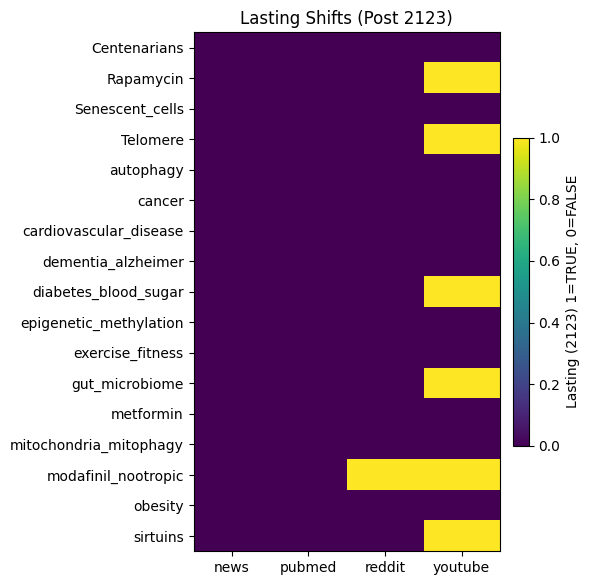

Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/plots/heatmap_delta_2123.png


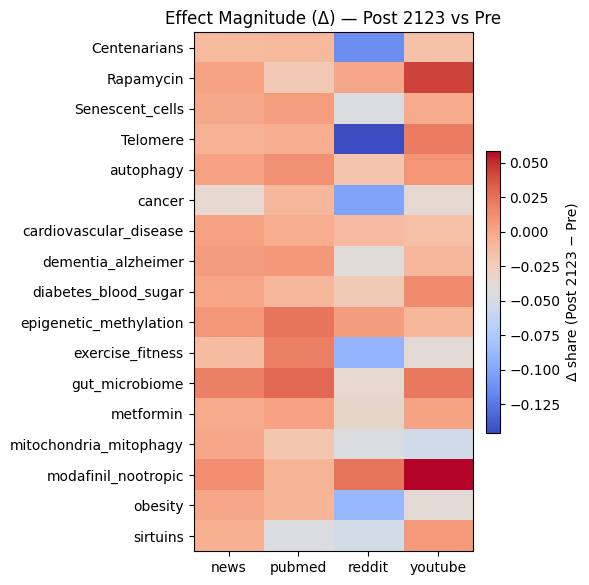

Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/plots/heatmap_delta_2125.png


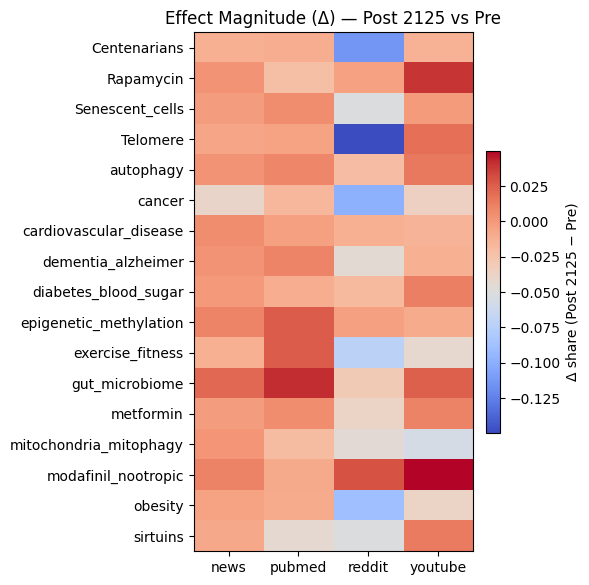

In [ ]:
# ===========================================
# Heatmaps
# ===========================================
def heatmap_lasting(df, post_window="2123", outfile=None):
    """
    Binary heatmap (lasting TRUE/FALSE) with topics as rows, platforms as columns.
    """
    df_named = df.copy()
    df_named["topic_label"] = df_named["topic_num"].astype(int).map(topic_names).fillna(df_named["topic_num"].astype(str))
    col = f"lasting_{post_window}"
    pivot = df_named.pivot(index="topic_label", columns="platform", values=col).astype(float)
    plt.figure(figsize=(6, max(4, 0.35 * pivot.shape[0])))
    im = plt.imshow(pivot.values, aspect="auto", interpolation="nearest")
    plt.colorbar(im, fraction=0.046, pad=0.04, label=f"Lasting ({post_window}) 1=TRUE, 0=FALSE")
    plt.yticks(ticks=np.arange(pivot.shape[0]), labels=pivot.index)
    plt.xticks(ticks=np.arange(pivot.shape[1]), labels=pivot.columns, rotation=0)
    plt.title(f"Lasting Shifts (Post {post_window})")
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=200)
        print("Saved →", outfile)
    plt.show()

def heatmap_delta(df, which="2123", outfile=None):
    """
    Continuous heatmap of Δ (post-pre mean share).
    """
    df_named = df.copy()
    df_named["topic_label"] = df_named["topic_num"].astype(int).map(topic_names).fillna(df_named["topic_num"].astype(str))
    pivot = df_named.pivot(index="topic_label", columns="platform", values=f"delta_{which}")
    plt.figure(figsize=(6, max(4, 0.35 * pivot.shape[0])))
    im = plt.imshow(pivot.values, aspect="auto", interpolation="nearest", cmap="coolwarm")
    plt.colorbar(im, fraction=0.046, pad=0.04, label=f"Δ share (Post {which} − Pre)")
    plt.yticks(ticks=np.arange(pivot.shape[0]), labels=pivot.index)
    plt.xticks(ticks=np.arange(pivot.shape[1]), labels=pivot.columns, rotation=0)
    plt.title(f"Effect Magnitude (Δ) — Post {which} vs Pre")
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=200)
        print("Saved →", outfile)
    plt.show()

# Generate heatmaps
heatmap_lasting(res, post_window="2123", outfile=f"{path}/plots/heatmap_lasting.png")
heatmap_delta(res, which="2123", outfile=f"{path}/plots/heatmap_delta_2123.png")
heatmap_delta(res, which="2125", outfile=f"{path}/plots/heatmap_delta_2125.png")

In [ ]:
res.groupby('platform').size()

,0
platform,
news,17
pubmed,17
reddit,17
youtube,17


#### COVID-period spike diagnostics

#### Code explanation: 
##### 1. The Immediate COVID Shock (ITS Step Change)

This section isolates the immediate, short-term impact of the pandemic declaration in March 2020.

- **FDR Correction:**  
  Applies the **Benjamini–Hochberg False Discovery Rate (FDR)** correction to the ITS level-change p-values (`p_post`)  
  to identify statistically valid, immediate jumps.

- **Output:**  
  `heatmap_covid_jump_its.png`

  - A **binary heatmap** showing which topics experienced a significant step-change  
  - Organized as **Topics × Platforms**  
  - Highlights where sudden shifts occurred at the onset of the pandemic  

---

##### 2. Shock-Year Magnitude & Volatility (2020)

This section focuses on the intensity and scale of topic changes during the main shock window:

- **Timeframe:** March–December 2020  
- **Baseline:** 2010–2019  

##### Key Metrics

- **`delta_2020`**  
  Measures the raw change in topic share:

  $$
  \Delta_{2020} = \mu_{2020} - \mu_{\text{pre}}
  $$

  - Visualized in: `heatmap_covid_delta2020.png`  
  - Captures overall increase or decrease during the shock period  

- **Peak Volatility ($Z$-score)**  
  Standardizes 2020 observations relative to historical behavior:

  $$
  Z = \frac{x - \mu_{\text{pre}}}{\sigma_{\text{pre}}}
  $$

  - Detects **short-lived spikes** in attention  
  - Useful for identifying bursty topics (e.g., sudden news cycles)  
  - Even if the yearly average remains moderate  

---

##### 3. Top Spike Extraction

- **Ranking Logic:**  
  - Groups data by **platform**  
  - Ranks topics by their **maximum 2020 $Z$-score** (descending)  

- **Output:**  
  `covid_spike_top_topics.csv`

  This file contains:
  - Top **5 most “shocked” topics per platform**  
  - The **month of peak intensity**  
  - The **magnitude of the spike**  

---

##### Purpose

This section complements the long-term ITS analysis by focusing on:

- Immediate pandemic shocks  
- Short-term volatility and attention spikes  
- Platform-specific reactions during the peak crisis period  

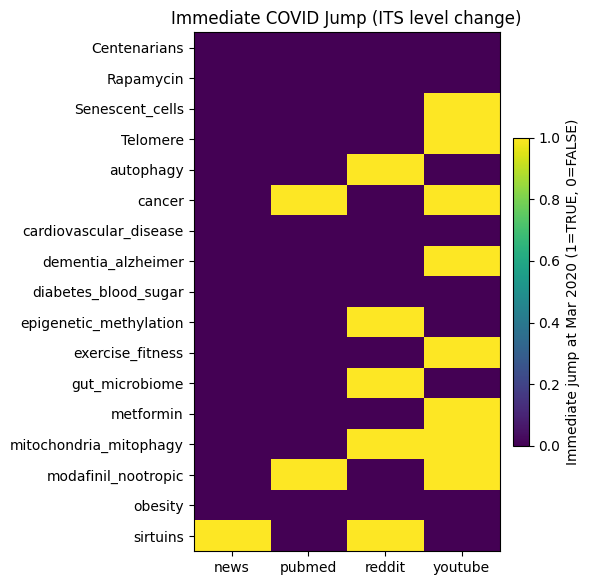

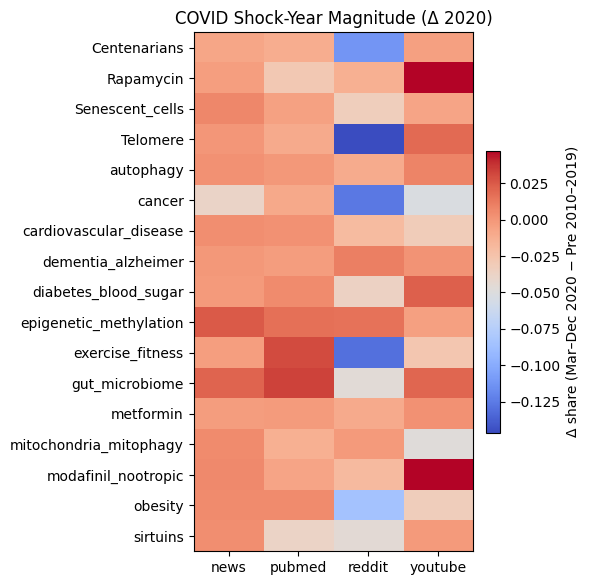

Saved:
 - heatmap_covid_jump_its.png (ITS immediate jump)
 - heatmap_covid_delta2020.png (shock-year Δ)
 - covid_spike_summary.csv (all metrics)
 - covid_spike_top_topics.csv (top spikes per platform)


In [ ]:
import pandas as pd, numpy as np
from pathlib import Path
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

OUT = path
shares = pd.read_csv(f"{path}/its_ready.csv", parse_dates=["month"])
its    = pd.read_csv(f"{path}/its_results_primary.csv")

# ---------- helper: BH-FDR per platform ----------
def fdr_by_platform(df, pcol, alpha=0.05):
    sig = pd.Series(False, index=df.index)
    for plat, g in df.groupby("platform"):
        p = g[pcol].astype(float).values
        mask = np.isfinite(p)
        if mask.sum()==0: continue
        rej, p_adj, *_ = multipletests(p[mask], alpha=alpha, method="fdr_bh")
        sig.loc[g.index[mask]] = rej
    return sig

# ---------- 1) Immediate jump (ITS level change at Mar 2020) ----------
its["sig_post_fdr"] = fdr_by_platform(its, "p_post", alpha=0.05)

# Pivot for heatmap: 1 = FDR-significant jump, 0 = not
its_named = its.copy()
its_named["topic_label"] = its_named["topic_num"].astype(int).map(topic_names).fillna(its_named["topic_num"].astype(str))
jump_map = its_named.pivot(index="topic_label", columns="platform", values="sig_post_fdr").astype(float).fillna(0.0)

plt.figure(figsize=(6, max(4, 0.35*jump_map.shape[0])))
im = plt.imshow(jump_map.values, aspect="auto", interpolation="nearest")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Immediate jump at Mar 2020 (1=TRUE, 0=FALSE)")
plt.yticks(np.arange(jump_map.shape[0]), jump_map.index)
plt.xticks(np.arange(jump_map.shape[1]), jump_map.columns)
plt.title("Immediate COVID Jump (ITS level change)")
plt.tight_layout()
plt.savefig(f"{path}/plots/heatmap_covid_jump_its.png", dpi=200)
plt.show()

# ---------- 2) Shock-year magnitude in 2020 ----------
PRE_START, PRE_END = pd.Timestamp("2010-01-01"), pd.Timestamp("2019-12-31")
COV_START, COV_END = pd.Timestamp("2020-03-01"), pd.Timestamp("2020-12-31")  # shock window

def period_mean(df, a, b):
    d = df[(df["month"]>=a) & (df["month"]<=b)]
    return np.nan if d.empty else float(d["share"].mean())

def period_sd(df, a, b):
    d = df[(df["month"]>=a) & (df["month"]<=b)]
    return np.nan if d.empty else float(d["share"].std(ddof=1))

rows=[]
for (plat, topic), g in shares.groupby(["platform","topic_num"], sort=False):
    g = g.sort_values("month")
    pre_mean = period_mean(g, PRE_START, PRE_END)
    pre_sd   = period_sd(g, PRE_START, PRE_END)
    cov_mean = period_mean(g, COV_START, COV_END)

    # Δ during 2020 shock window (Mar–Dec)
    delta_2020 = (cov_mean - pre_mean) if (np.isfinite(pre_mean) and np.isfinite(cov_mean)) else np.nan

    # Peak z-score within 2020 relative to pre mean/sd
    g2020 = g[(g["month"]>=COV_START) & (g["month"]<=COV_END)].copy()
    if np.isfinite(pre_mean) and np.isfinite(pre_sd) and pre_sd>0 and not g2020.empty:
        g2020["z"] = (g2020["share"] - pre_mean)/pre_sd
        peak_z = float(g2020["z"].max())
        peak_month = g2020.loc[g2020["z"].idxmax(), "month"]
    else:
        peak_z, peak_month = np.nan, pd.NaT

    rows.append({
        "platform": plat, "topic_num": topic,
        "pre_mean": pre_mean, "pre_sd": pre_sd,
        "covid2020_mean": cov_mean, "delta_2020": delta_2020,
        "peak_z_2020": peak_z, "peak_month_2020": peak_month
    })

cov = pd.DataFrame(rows)
cov.to_csv(f"{path}/plots/covid_spike_summary.csv", index=False)

# Heatmap of Δ_2020 (Mar–Dec 2020 vs pre)
cov_named = cov.copy()
cov_named["topic_label"] = cov_named["topic_num"].astype(int).map(topic_names).fillna(cov_named["topic_num"].astype(str))
delta_map = cov_named.pivot(index="topic_label", columns="platform", values="delta_2020")
plt.figure(figsize=(6, max(4, 0.35*delta_map.shape[0])))
im = plt.imshow(delta_map.values, aspect="auto", interpolation="nearest", cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Δ share (Mar–Dec 2020 − Pre 2010–2019)")
plt.yticks(np.arange(delta_map.shape[0]), delta_map.index)
plt.xticks(np.arange(delta_map.shape[1]), delta_map.columns)
plt.title("COVID Shock-Year Magnitude (Δ 2020)")
plt.tight_layout()
plt.savefig(f"{path}/plots/heatmap_covid_delta2020.png", dpi=200)
plt.show()

# ---------- 3) Top spike topics per platform (by peak z in 2020) ----------
top_rows = []
for plat, g in cov.groupby("platform"):
    g2 = g.dropna(subset=["peak_z_2020"]).sort_values("peak_z_2020", ascending=False).head(5)
    g2 = g2.assign(rank=np.arange(1, len(g2)+1))
    top_rows.append(g2[["platform","rank","topic_num","peak_z_2020","peak_month_2020","delta_2020"]])
tops = pd.concat(top_rows, ignore_index=True)
tops.to_csv(f"{path}/covid_spike_top_topics.csv", index=False)
print("Saved:")
print(" - heatmap_covid_jump_its.png (ITS immediate jump)")
print(" - heatmap_covid_delta2020.png (shock-year Δ)")
print(" - covid_spike_summary.csv (all metrics)")
print(" - covid_spike_top_topics.csv (top spikes per platform)")


#### Sensitivity analysis

#### Code explanation

##### 1. Parameter Grid Search (Sensitivity Sweep)

This step rigorously tests the robustness of the "lasting shift" conclusions by executing a grid search across multiple arbitrary thresholds. It ensures that the results are not simply artifacts of the specific parameters chosen in earlier steps.

- **FDR Levels (alpha):** Tests strict (0.01) to more lenient (0.10) significance thresholds.  
- **Effect Sizes (dthr):** Tests small (0.20), medium (0.30), and large (0.50) Cohen's $d$ magnitude cutoffs.  
- **Directionality:** Tests looking strictly for growth (increase) versus any directional shift (either).  
- **Time Windows:** Tests sensitivity to the baseline choice (10-year pre-window vs. 2-year immediate pre-window) and the post-pandemic evaluation window (ending 2023 vs. 2025).  

The script uses `itertools.product` to calculate the ITS significance and persistence metrics for every possible combination of these parameters.

---

##### 2. Robustness Visualization

Instead of producing a binary "True/False" flag, this section aggregates the sweep results to show how often a topic was flagged as lasting across all tested specifications.

- **`fraction_heatmap(...)`**  
  Generates a heatmap where values range from:
  - **0:** Never lasting under any criteria  
  - **1:** Always lasting regardless of strictness  

Topics with a high fraction (e.g., > 0.8) represent deeply robust structural shifts that hold up regardless of the statistical parameters applied.

---

##### 3. Aggregate Reporting

- **`lasting_counts_by_spec.csv`**  
  Produces a supplemental summary table that counts how many total topics were flagged as "lasting" for each parameter combination, broken down by platform.  

This is particularly useful for methodological appendices to demonstrate the overall stability of the findings.

Saved →/content/drive/MyDrive/Keyword-analysis/rq3/out/lasting_sensitivity.csv


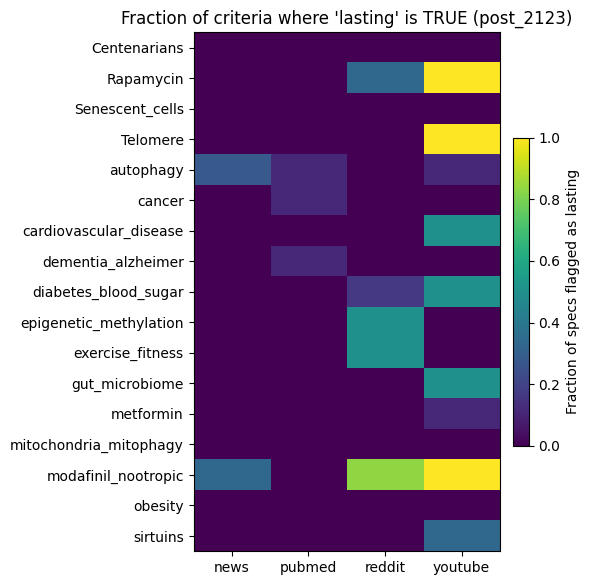

Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/plots/lasting_fraction_2123.png


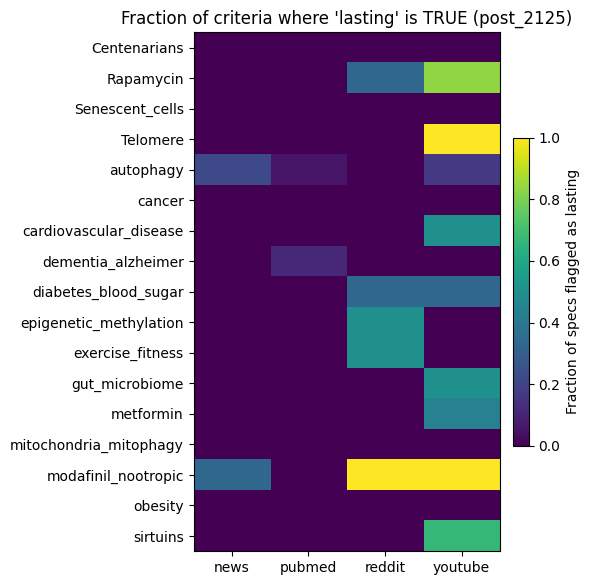

Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/plots/lasting_fraction_2125.png
Saved →/content/drive/MyDrive/Keyword-analysis/rq3/outlasting_counts_by_spec.csv


In [ ]:
# ===========================================
# Sensitivity sweep for "lasting" criteria
# ===========================================
import pandas as pd, numpy as np
from pathlib import Path
from statsmodels.stats.multitest import multipletests
import itertools
import matplotlib.pyplot as plt

ITS_FILE    = f"{path}/its_results_primary.csv"  # from Step 4
SHARES_FILE =f"{path}/its_ready.csv"            # from Step 3

# ----------------- knobs to sweep -----------------
ALPHAS        = [0.01, 0.05, 0.10]          # FDR levels
D_THRESHOLDS  = [0.20, 0.30, 0.50]          # effect-size (Cohen's d) cutoffs
DIRECTIONS    = ["increase", "either"]      # or "decrease"

# Pre/post windows to test (label, (start, end) as ISO strings)
PRE_WINDOWS  = [
    ("pre_2010_2019", ("2010-01-01", "2019-12-31")),
    ("pre_2018_2019", ("2018-01-01", "2019-12-31")),
]
POST_WINDOWS = [
    ("post_2123", ("2021-01-01", "2023-12-31")),
    ("post_2125", ("2021-01-01", "2025-12-31")),
]

# ----------------- helpers -----------------
def fdr_by_platform(df, pcol, alpha=0.05):
    sig = pd.Series(False, index=df.index)
    for plat, g in df.groupby("platform"):
        p = g[pcol].astype(float).values
        mask = np.isfinite(p)
        if mask.sum() == 0:
            continue
        rej, p_adj, *_ = multipletests(p[mask], alpha=alpha, method="fdr_bh")
        sig.loc[g.index[mask]] = rej
    return sig

def period_mean_sd(df, start_ts, end_ts):
    d = df[(df["month"] >= start_ts) & (df["month"] <= end_ts)]
    if d.empty:
        return np.nan, np.nan
    return float(d["share"].mean()), float(d["share"].std(ddof=1))

def direction_ok(delta, mode):
    if not np.isfinite(delta):
        return False
    if mode == "increase":
        return delta > 0
    if mode == "decrease":
        return delta < 0
    return delta != 0  # "either"

# ----------------- load data -----------------
its = pd.read_csv(ITS_FILE)
share = pd.read_csv(SHARES_FILE, parse_dates=["month"])

# sanity
need_its   = {"platform","topic_num","p_post","p_tpost"}
need_share = {"platform","topic_num","month","share"}
if (need_its - set(its.columns)) or (need_share - set(share.columns)):
    raise ValueError("Missing required columns in ITS or shares files.")

# ----------------- sweep -----------------
spec_rows = []
for (pre_lab, (pre_s, pre_e)), (post_lab, (post_s, post_e)), alpha, dthr, direct in itertools.product(
    PRE_WINDOWS, POST_WINDOWS, ALPHAS, D_THRESHOLDS, DIRECTIONS
):
    pre_s, pre_e   = pd.Timestamp(pre_s),  pd.Timestamp(pre_e)
    post_s, post_e = pd.Timestamp(post_s), pd.Timestamp(post_e)

    its_tmp = its.copy()
    its_tmp["sig_post_fdr"]  = fdr_by_platform(its_tmp, "p_post",  alpha)
    its_tmp["sig_tpost_fdr"] = fdr_by_platform(its_tmp, "p_tpost", alpha)

    # compute persistence for this spec
    rows = []
    for (plat, topic), g in share.groupby(["platform","topic_num"], sort=False):
        g = g.sort_values("month")
        pre_mean, pre_sd = period_mean_sd(g, pre_s, pre_e)
        post_mean, _     = period_mean_sd(g, post_s, post_e)
        delta = post_mean - pre_mean if (np.isfinite(pre_mean) and np.isfinite(post_mean)) else np.nan
        dval  = (delta / pre_sd) if (np.isfinite(delta) and np.isfinite(pre_sd) and pre_sd > 0) else np.nan
        persist = direction_ok(delta, direct) and (np.isfinite(dval) and dval >= dthr)
        rows.append({
            "platform": plat, "topic_num": topic,
            "pre_label": pre_lab, "post_label": post_lab,
            "alpha_fdr": alpha, "d_threshold": dthr, "direction": direct,
            "pre_mean": pre_mean, "post_mean": post_mean, "delta": delta, "d": dval,
            "persist": persist
        })
    pers = pd.DataFrame(rows)

    # join with significance and finalize lasting flag
    res = pers.merge(its_tmp[["platform","topic_num","sig_post_fdr","sig_tpost_fdr"]],
                     on=["platform","topic_num"], how="left")
    res["lasting"] = (res["sig_post_fdr"] | res["sig_tpost_fdr"]) & res["persist"]

    spec_rows.append(res)

sens = pd.concat(spec_rows, ignore_index=True)
sens.to_csv(f"{path}/lasting_sensitivity.csv", index=False)
print(f"Saved →{path}/lasting_sensitivity.csv")

# ----------------- summarize: fraction lasting per (platform, topic) -----------------
def fraction_heatmap(df, post_label, outfile):
    df_named = df.copy()
    df_named["topic_label"] = df_named["topic_num"].astype(int).map(topic_names).fillna(df_named["topic_num"].astype(str))
    d = df_named[df_named["post_label"] == post_label]
    frac = (
        d.groupby(["topic_label","platform"])["lasting"]
         .mean()  # fraction of specs where lasting==True
         .unstack("platform")
         .sort_index()
    )
    plt.figure(figsize=(6, max(4, 0.35*frac.shape[0])))
    im = plt.imshow(frac.values, aspect="auto", interpolation="nearest")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Fraction of specs flagged as lasting")
    plt.yticks(np.arange(frac.shape[0]), frac.index)
    plt.xticks(np.arange(frac.shape[1]), frac.columns)
    plt.title(f"Fraction of criteria where 'lasting' is TRUE ({post_label})")
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.show()
    print("Saved →", outfile)

fraction_heatmap(sens, "post_2123", f"{path}/plots/lasting_fraction_2123.png")
fraction_heatmap(sens, "post_2125", f"{path}/plots/lasting_fraction_2125.png")

# ----------------- counts by spec (useful table for paper/supplement) -----------------
counts = (
    sens.groupby(["pre_label","post_label","alpha_fdr","d_threshold","direction","platform"])["lasting"]
        .sum()
        .rename("n_lasting_topics")
        .reset_index()
        .sort_values(["post_label","platform","alpha_fdr","d_threshold","direction"])
)
counts.to_csv(f"{path}/lasting_counts_by_spec.csv", index=False)
print(f"Saved →{path}lasting_counts_by_spec.csv")


#### Time series for specific topics
##### Code explanation: 
##### Overview & Time Periods
This cell generates event-study style time series plots for specific topics. It is used to visually validate the statistical findings by plotting the raw data trajectory of a topic over time, making it easy to see the difference between a temporary "spike" and a permanent "lasting shift."

It defines three distinct temporal windows for visual shading:

- Pre-Period (2010–2019): The historical baseline.

- Shock Period (2020): The immediate volatility following the COVID-19 pandemic declaration.

- Post-Period (2021–2025): The "new normal" window used to evaluate persistence.

In [ ]:
# ===========================================
# Event-study style time series plot for selected topics
# ===========================================
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SHARES_FILE = f"{path}/its_ready.csv"

# Load data
df = pd.read_csv(SHARES_FILE, parse_dates=["month"])


# --------- parameters you can adjust ----------
BREAK_DATE = pd.Timestamp("2020-03-01")
PRE_PERIOD = (pd.Timestamp("2010-01-01"), pd.Timestamp("2019-12-31"))
SHOCK_PERIOD = (pd.Timestamp("2020-03-01"), pd.Timestamp("2020-12-31"))
POST_PERIOD = (pd.Timestamp("2021-01-01"), pd.Timestamp("2025-12-31"))

# Topics/platforms to plot (e.g., lasting vs non-lasting)
PLOTS = [
    {"platform": "reddit", "topic_num": 16, "label": "Topic Modafinil nootropic (lasting)"},
    {"platform": "reddit", "topic_num": 8,  "label": "Topic Gut microbiome (non-lasting)"}
]

# --------- plotting function ----------
def plot_event_study(platform, topic_num, label=None, save=True):
    sel = df[(df["platform"] == platform) & (df["topic_num"] == topic_num)].copy()
    sel = sel.sort_values("month")

    if sel.empty:
        print(f"⚠ No data for platform={platform}, topic={topic_num}")
        return

    plt.figure(figsize=(12, 5))
    plt.plot(sel["month"], sel["share"], marker="o", markersize=2, label="Monthly share")

    # Mark periods
    plt.axvline(BREAK_DATE, color="k", linestyle="--", label="COVID break (Mar 2020)")
    plt.axvspan(PRE_PERIOD[0], PRE_PERIOD[1], color="gray", alpha=0.1, label="Pre")
    plt.axvspan(SHOCK_PERIOD[0], SHOCK_PERIOD[1], color="orange", alpha=0.1, label="Shock 2020")
    plt.axvspan(POST_PERIOD[0], POST_PERIOD[1], color="green", alpha=0.05, label="Post")

    plt.title(f"Event Study — {label or f'{platform} Topic {topic_num}'}")
    plt.xlabel("Month")
    plt.ylabel("Topic share")
    plt.grid(alpha=0.3)
    plt.legend(loc="upper left")
    plt.tight_layout()

    if save:
        fname = f"{path}/plots/eventstudy_{platform}_topic{topic_num}.png"
        plt.savefig(fname, dpi=200)
        print(f"Saved → {fname}")
    plt.close()

# --------- generate plots ----------
for p in PLOTS:
    plot_event_study(p["platform"], p["topic_num"], p.get("label"))


Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/plots/eventstudy_reddit_topic16.png
Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/plots/eventstudy_reddit_topic8.png


## Log odds

#### Code explanation

##### 1. Overview & Data Preparation

This cell shifts the focus from topic volume to narrative content. It analyzes how the actual vocabulary used within a specific topic changed after the pandemic by comparing term frequencies in a pre-period (2010–2019) against a post-period (2021–2023).

- **`infer_year(df, platform)`**  
  A robust utility that handles the messy reality of cross-platform data. It locates the correct date or timestamp column based on the platform's schema and extracts a normalized year column for filtering.

- **Text Processing:**  
  The `tokenize`, `bigrams`, and `get_counts` functions handle basic NLP tasks, extracting both:
  - Single words (**unigrams**)  
  - Two-word phrases (**bigrams**)  

  This enables capturing richer contextual meaning in the analysis.

---

##### 2. Core Statistical Method: Monroe Log-Odds

- **`log_odds_with_informative_prior(...)`**

Simple word frequency comparisons are easily skewed by common words. This function implements the **Monroe et al. (2008) log-odds ratio with an informative Dirichlet prior**, a standard method in computational social science for identifying distinguishing terms between two corpora.

- **The Prior:**  
  Uses pooled counts from both time periods as the baseline expectation (informative prior)

- **The Math:**  
  Computes the log-odds of a word appearing in the post-period vs. the pre-period, smoothed by the prior ($\alpha$)

- **The Output ($Z$-score):**

  $$
  Z = \frac{\text{log-odds}}{\sqrt{\text{variance}}}
  $$

  - High positive $Z$: Term is characteristic of the **post-pandemic** period  
  - High negative $Z$: Term is characteristic of the **pre-pandemic** period  

---

##### 3. Main Execution & Output

- **`run_log_odds_prepost(datasets, ...)`**

This wrapper iterates through every platform and every topic, performing the log-odds comparison.

- **Filtering:**  
  - Selects **top 50 terms** where post > pre  
  - Selects **top 50 terms** where pre > post  
  - Removes statistically insignificant middle terms  

- **Output:**  
  Generates a dedicated CSV file for each platform-topic pair  
  (e.g., `lexical_shift_reddit_Rapamycin.csv`)

These outputs provide the qualitative narrative behind the quantitative topic trends identified earlier.

In [ ]:
# ===========================================
# Step 8a: Log-odds with informative prior (pre vs post) per platform × topic
# Works with: datasets = {'Reddit': rd, 'News': nw, 'PubMed': pm}
# Requires each df to contain: 'topic_num', 'text_clean' and a date column (platform-specific).
# ===========================================
import pandas as pd
import numpy as np
from collections import Counter
from itertools import tee
from pathlib import Path
import math

# ---------- CONFIG ----------
PRE_YEARS  = range(2010, 2020)   # 2010–2019
POST_YEARS = range(2021, 2024)   # 2021–2023 (persistence window)
INCLUDE_BIGRAMS = True
ALPHA_PRIOR = 1.0                 # Monroe prior strength (Dirichlet concentration)
OUT_DIR = f"/{path}/narrative_shift"

# Optional: topic name mapping for nicer filenames/columns
topic_names = {
    0: "Centenarians", 1: "Senescent_cells", 2: "Telomere", 3: "Rapamycin",
    4: "metformin", 5: "dementia_alzheimer", 6: "exercise_fitness",
    7: "diabetes_blood_sugar", 8: "gut_microbiome", 9: "epigenetic_methylation",
    10: "mitochondria_mitophagy", 11: "sirtuins", 12: "autophagy",
    13: "cardiovascular_disease", 14: "obesity", 15: "cancer",
    16: "modafinil_nootropic",
}

# ---------- HELPERS ----------
def infer_year(df, platform):
    """Add a 'year' column using platform-specific date columns."""
    d = df.copy()
    pl = platform.lower()

    if pl == "reddit":
        if "ts_utc" in d.columns:
            dates = pd.to_datetime(d["ts_utc"], errors="coerce", utc=True)
        elif "ts_seconds" in d.columns:
            dates = pd.to_datetime(d["ts_seconds"], unit="s", errors="coerce", utc=True)
        else:
            raise ValueError("Reddit df needs 'ts_utc' or 'ts_seconds'")

    elif pl == "news":
        if "Publication date" in d.columns:
            dates = pd.to_datetime(d["Publication date"], errors="coerce")
        elif "Publication year" in d.columns:
            yr = pd.to_numeric(d["Publication year"], errors="coerce")
            dates = pd.to_datetime(dict(year=yr, month=7, day=1), errors="coerce")
        else:
            raise ValueError("News df needs 'Publication date' or 'Publication year'")

    elif pl == "pubmed":
        # your dataset uses 'date' or 'year'
        if "date" in d.columns:
            dates = pd.to_datetime(d["date"], errors="coerce")
        elif "year" in d.columns:
            yr = pd.to_numeric(d["year"], errors="coerce")
            dates = pd.to_datetime(dict(year=yr, month=7, day=1), errors="coerce")
        else:
            raise ValueError("PubMed df needs 'date' or 'year'")

    elif pl == "youtube":
        # YouTube columns (from your schema): 'date' or fallback 'year'
        if "date" in d.columns:
            dates = pd.to_datetime(d["date"], errors="coerce")
        elif "year" in d.columns:
            yr = pd.to_numeric(d["year"], errors="coerce")
            dates = pd.to_datetime(dict(year=yr, month=7, day=1), errors="coerce")
        else:
            raise ValueError("YouTube df needs 'date' or 'year'")

    else:
        # generic fallback: try common date columns
        col = next((c for c in d.columns if c.lower() in {"date","pub_date","ts_utc"}), None)
        if col:
            dates = pd.to_datetime(d[col], errors="coerce")
        else:
            raise ValueError(f"Cannot infer date column for platform {platform}")

    d["year"] = dates.dt.year
    return d


def tokenize(text):
    if not isinstance(text, str):
        return []
    return [t for t in text.split() if t]

def bigrams(tokens):
    if len(tokens) < 2:
        return []
    a, b = tee(tokens)
    next(b, None)
    return [f"{x}_{y}" for x, y in zip(a, b)]

def get_counts(frame, include_bigrams=True):
    """Return Counter of unigrams (+ optional bigrams) from 'text_clean' column."""
    cnt = Counter()
    for txt in frame["text_clean"]:
        toks = tokenize(txt)
        if not toks:
            continue
        cnt.update(toks)
        if include_bigrams:
            cnt.update(bigrams(toks))
    return cnt

def log_odds_with_informative_prior(counts_A, counts_B, prior_counts, alpha=1.0):
    """
    Monroe et al. (2008) log-odds with informative Dirichlet prior.
    Returns DataFrame with term, log_odds (A vs B), z, count_A, count_B.
    """
    vocab = set(counts_A) | set(counts_B) | set(prior_counts)
    NA = sum(counts_A.values()); NB = sum(counts_B.values()); N0 = sum(prior_counts.values())
    out = []
    for term in vocab:
        a = counts_A.get(term, 0); b = counts_B.get(term, 0); p0 = prior_counts.get(term, 0)
        # posterior means with prior
        num = (a + alpha * (p0 / N0)) / (NA + alpha)
        den = (b + alpha * (p0 / N0)) / (NB + alpha)
        logodds = math.log(num / den)
        var = 1.0 / (a + alpha * (p0 / N0)) + 1.0 / (b + alpha * (p0 / N0))
        z = logodds / math.sqrt(var)
        out.append((term, logodds, z, a, b))
    return pd.DataFrame(out, columns=["term","log_odds","z","count_post","count_pre"])

# ---------- MAIN ----------
def run_log_odds_prepost(datasets, include_bigrams=INCLUDE_BIGRAMS, alpha=ALPHA_PRIOR):
    """
    For each platform×topic: compute post(2021–2023) vs pre(2010–2019) log-odds with prior.
    Writes CSV to OUT_DIR and returns a dict of DataFrames.
    """
    results = {}
    for platform, df in datasets.items():
        # minimal column checks
        for col in ["topic_num", "text_clean"]:
            if col not in df.columns:
                raise ValueError(f"{platform} df missing '{col}'")

        d = infer_year(df, platform).dropna(subset=["year", "topic_num", "text_clean"]).copy()
        d["topic_num"] = pd.to_numeric(d["topic_num"], errors="coerce")

        for topic, g in d.groupby("topic_num", sort=False):
            pre_df  = g[g["year"].isin(PRE_YEARS)]
            post_df = g[g["year"].isin(POST_YEARS)]
            if pre_df.empty or post_df.empty:
                continue  # need both sides

            # Prior: pooled counts over BOTH periods within this platform×topic
            pooled_prior = get_counts(pd.concat([pre_df, post_df], ignore_index=True), include_bigrams)
            pre_counts   = get_counts(pre_df, include_bigrams)
            post_counts  = get_counts(post_df, include_bigrams)

            logodds = log_odds_with_informative_prior(post_counts, pre_counts, pooled_prior, alpha=alpha)
            # rank by |z|
            logodds = logodds.sort_values("z", ascending=False)

            # split top K per direction (tune K as needed)
            K = 50
            top_post = logodds.head(K).assign(direction="post>pre")
            top_pre  = logodds.tail(K).assign(direction="pre>post")
            out_df = pd.concat([top_post, top_pre], ignore_index=True)

            # Add metadata
            out_df.insert(0, "platform", platform)
            out_df.insert(1, "topic_num", topic)
            if topic in topic_names:
                out_df.insert(2, "topic_name", topic_names[int(topic)])

            # Save
            safe_topic = topic_names.get(int(topic), f"topic{int(topic)}")
            outfile = f"{OUT_DIR}/lexical_shift_{platform.lower()}_{safe_topic}.csv"
            out_df.to_csv(outfile, index=False)
            results[(platform, int(topic))] = out_df
            print(f"Saved → {outfile} (pre n={len(pre_df)}, post n={len(post_df)}, vocab={len(logodds)})")
    return results




In [ ]:
# ---------- RUN ----------
results_dict = run_log_odds_prepost(datasets)

Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/lexical_shift_reddit_Centenarians.csv (pre n=61, post n=72, vocab=1962)
Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/lexical_shift_reddit_Senescent_cells.csv (pre n=143, post n=182, vocab=5640)
Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/lexical_shift_reddit_Telomere.csv (pre n=188, post n=153, vocab=4777)
Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/lexical_shift_reddit_Rapamycin.csv (pre n=67, post n=267, vocab=4304)
Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/lexical_shift_reddit_metformin.csv (pre n=147, post n=223, vocab=7292)
Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/lexical_shift_reddit_dementia_alzheimer.csv (pre n=386, post n=662, vocab=15377)
Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/lexical_shift_reddit_exercise_fitness.csv (pre n

#### Code explanation

##### Overview & Data Retrieval
This cell visualizes the results of the Monroe log-odds analysis from the previous step. It takes the raw vocabulary statistics and turns them into highly readable horizontal bar charts to illustrate how a topic's narrative focus shifted before and after the pandemic.

- _load_logodds(...): A helper function that automatically fetches the correct CSV generated in Step 8a based on the specified platform and topic ID.

- Topic Mapping: Uses the topic_names dictionary to ensure the charts feature human-readable titles (e.g., "Rapamycin") rather than abstract numerical IDs.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = f"/{path}/narrative_shift"

# Optional: your topic names for nicer titles
topic_names = {
    0:"Centenarians", 1:"Senescent_cells", 2:"Telomere", 3:"Rapamycin",
    4:"metformin", 5:"dementia_alzheimer", 6:"exercise_fitness",
    7:"diabetes_blood_sugar", 8:"gut_microbiome", 9:"epigenetic_methylation",
    10:"mitochondria_mitophagy", 11:"sirtuins", 12:"autophagy",
    13:"cardiovascular_disease", 14:"obesity", 15:"cancer",
    16:"modafinil_nootropic",
}

def _safe_topic_label(topic):
    try:
        t = int(topic)
    except Exception:
        return str(topic)
    return topic_names.get(t, f"topic{t}")

def _load_logodds(platform: str, topic_num: int, results: dict | None = None):
    """
    Load log-odds results for (platform, topic_num) from:
      - results dict (if provided), else
      - CSV file saved by run_log_odds_prepost.
    Returns a DataFrame with columns: term, log_odds, z, count_post, count_pre, direction
    """
    if results is not None and (platform, int(topic_num)) in results:
        return results[(platform, int(topic_num))].copy()

    # fall back to CSV
    safe_topic = _safe_topic_label(topic_num)
    candidate = f"{OUT_DIR}/lexical_shift_{platform.lower()}_{safe_topic}.csv"
    # if not candidate.exists():
    #     raise FileNotFoundError(
    #         f"Could not find {candidate}. Pass `results=` from run_log_odds_prepost() "
    #         "or check OUT_DIR and filename pattern."
    #     )
    return pd.read_csv(candidate)

def _shorten(s, maxlen=28):
    s = str(s)
    return s if len(s) <= maxlen else s[:maxlen-1] + "…"

def plot_logodds_bars(platform: str,
                      topic_num: int,
                      results: dict | None = None,
                      top_k: int = 15,
                      score_col: str = "z",
                      save=True):
    """
    Make TWO figures:
      (1) Top-K terms enriched POST > PRE   (score by `score_col`, default Z)
      (2) Top-K terms enriched PRE  > POST
    Arguments
    ---------
    platform : "Reddit" | "News" | "PubMed"
    topic_num: int topic id
    results  : dict returned by run_log_odds_prepost (optional). If None, loads CSV.
    top_k    : how many bars per chart
    score_col: "z" or "log_odds" (use "z" for ranking stability)
    """
    df = _load_logodds(platform, topic_num, results)
    if df.empty:
        print("No log-odds rows for this (platform, topic).")
        return

    # split directions and rank
    post = df[df["direction"] == "post>pre"].sort_values(score_col, ascending=False).head(top_k).copy()
    pre  = df[df["direction"] == "pre>post"].sort_values(score_col, ascending=True).head(top_k).copy()  # ascending because z is negative here

    topic_label = _safe_topic_label(topic_num)
    # --------- Figure 1: POST > PRE ---------
    plt.figure(figsize=(10, max(4, 0.45 * len(post))))
    y = np.arange(len(post))
    plt.barh(y, post[score_col].values)
    plt.yticks(y, [ _shorten(t) for t in post["term"] ])
    plt.gca().invert_yaxis()
    plt.xlabel(f"{score_col.upper()} (higher ⇒ stronger POST enrichment)")
    plt.title(f"{platform} — {topic_label}\nPost (2021–2023) vs Pre (2010–2019): Top {len(post)} enriched terms")
    # annotate counts (post/pre) at bar ends
    for i, (v, cp, cr) in enumerate(zip(post[score_col].values, post["count_post"].values, post["count_pre"].values)):
        plt.text(v, i, f"  [{int(cp)}/{int(cr)}]", va="center")
    plt.tight_layout()
    if save:
        out1 = f"{OUT_DIR}/plots/logodds_{platform.lower()}_{topic_label}_post_gt_pre.png"
        plt.savefig(out1, dpi=200)
        print("Saved →", out1)
    plt.show()

    # --------- Figure 2: PRE > POST ---------
    plt.figure(figsize=(10, max(4, 0.45 * len(pre))))
    y = np.arange(len(pre))
    plt.barh(y, -pre[score_col].values)  # flip so bigger bar = stronger PRE enrichment
    plt.yticks(y, [ _shorten(t) for t in pre["term"] ])
    plt.gca().invert_yaxis()
    plt.xlabel(f"{score_col.upper()} (higher ⇒ stronger PRE enrichment)")
    plt.title(f"{platform} — {topic_label}\nPre (2010–2019) vs Post (2021–2023): Top {len(pre)} enriched terms")
    for i, (v, cp, cr) in enumerate(zip(pre[score_col].values, pre["count_post"].values, pre["count_pre"].values)):
        plt.text(-v, i, f"  [{int(cr)}/{int(cp)}]", va="center")  # show pre/post counts in same order
    plt.tight_layout()
    if save:
        out2 =f"{OUT_DIR}/plots/logodds_{platform.lower()}_{topic_label}_pre_gt_post.png"
        plt.savefig(out2, dpi=200)
        print("Saved →", out2)
    plt.show()


Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/plots/logodds_reddit_modafinil_nootropic_post_gt_pre.png


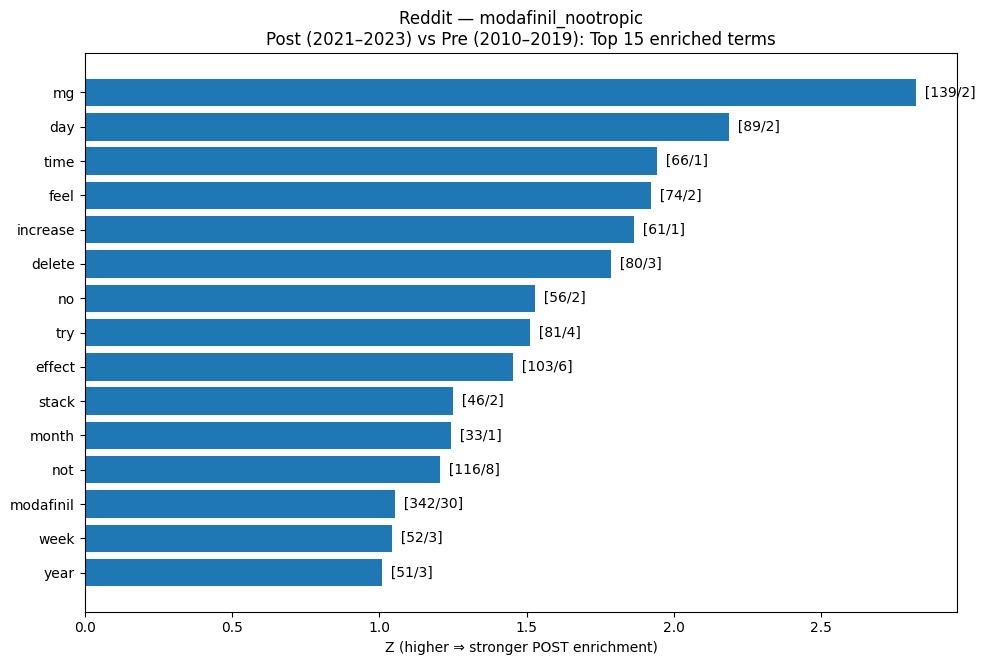

Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/plots/logodds_reddit_modafinil_nootropic_pre_gt_post.png


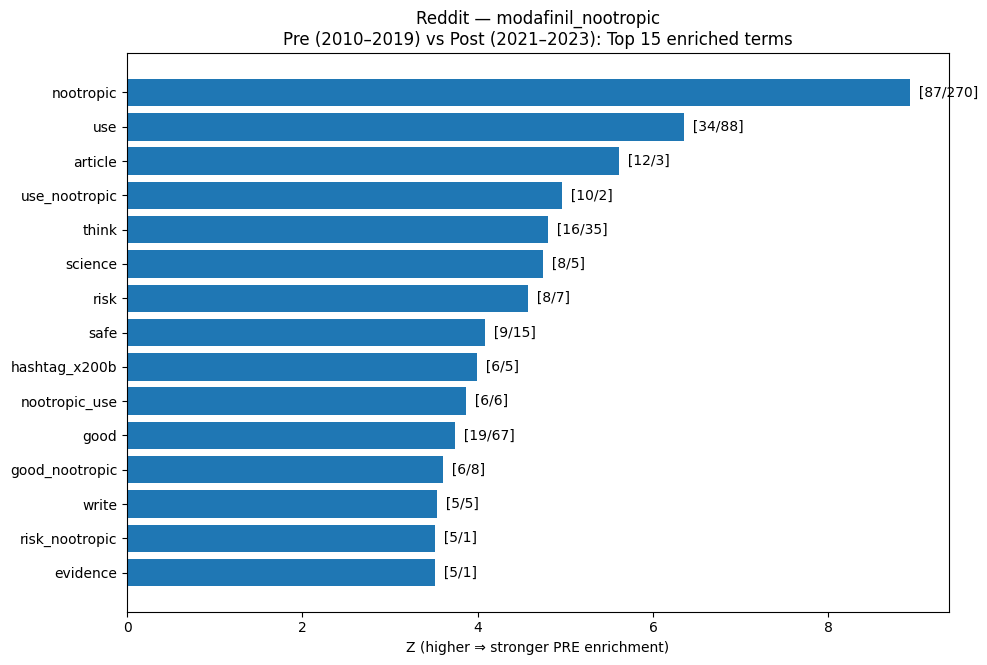

In [ ]:
# Example line for generating the graph for log odds
plot_logodds_bars("Reddit", 16, results=None, top_k=15, score_col="z")

Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/plots/logodds_pubmed_dementia_alzheimer_post_gt_pre.png


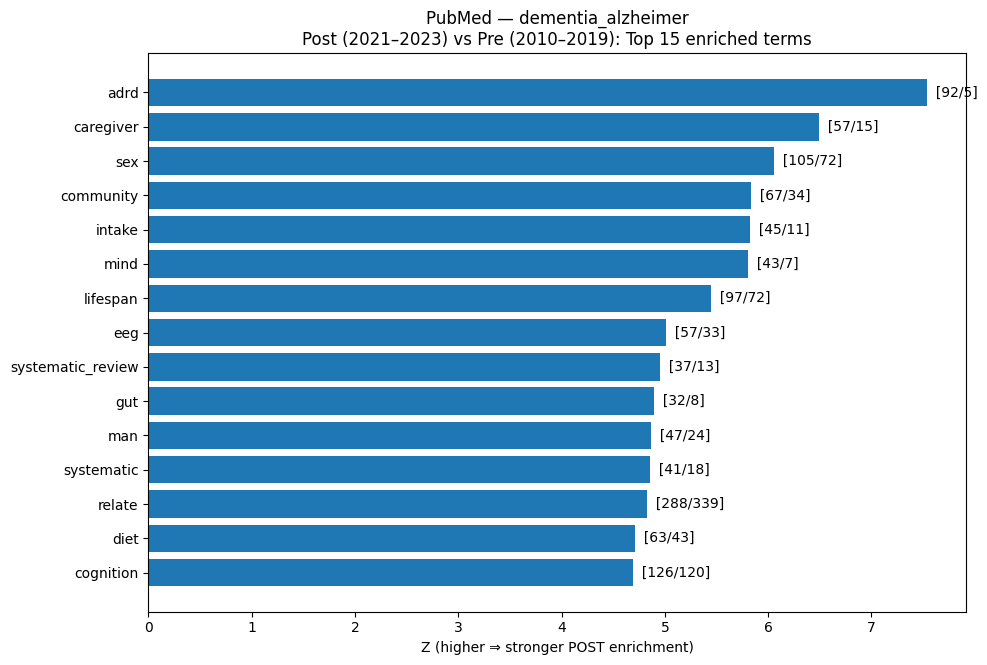

Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/plots/logodds_pubmed_dementia_alzheimer_pre_gt_post.png


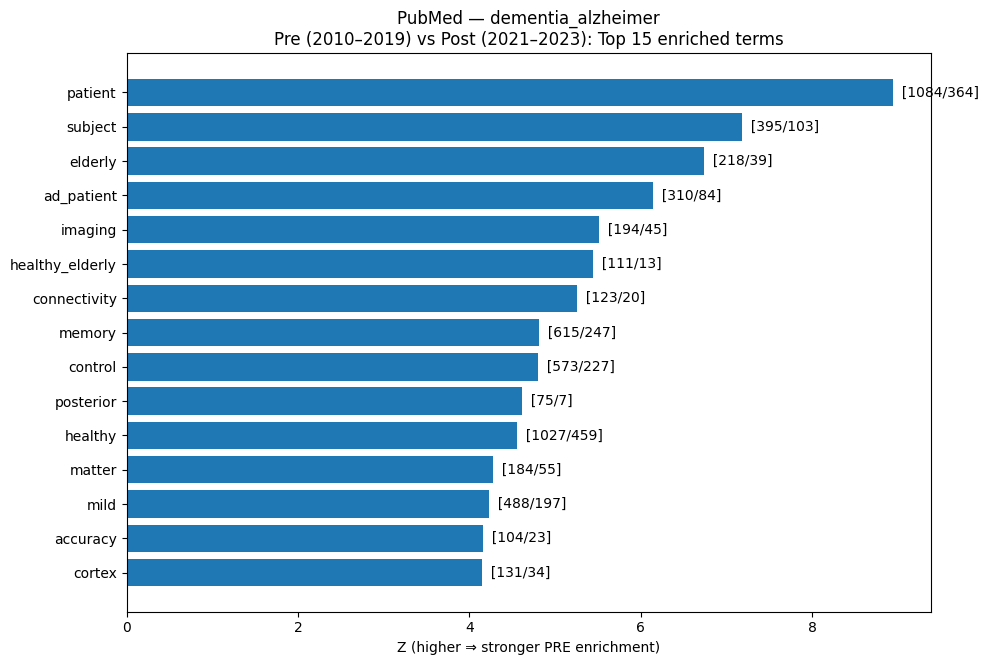

In [ ]:
plot_logodds_bars("PubMed", 5, results=None, top_k=15, score_col="z")

Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/plots/logodds_news_autophagy_post_gt_pre.png


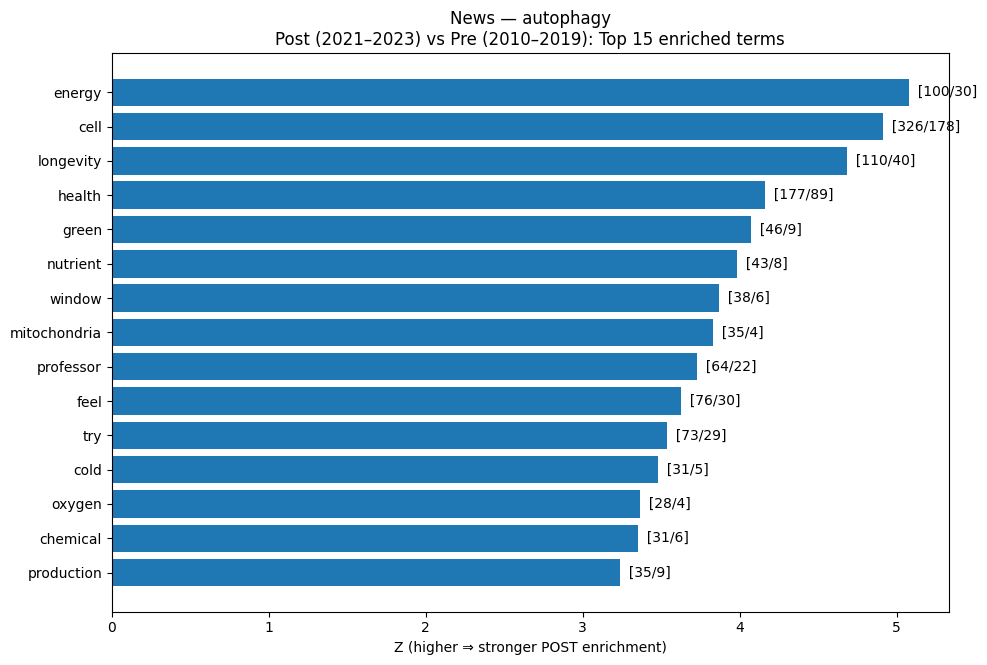

Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/plots/logodds_news_autophagy_pre_gt_post.png


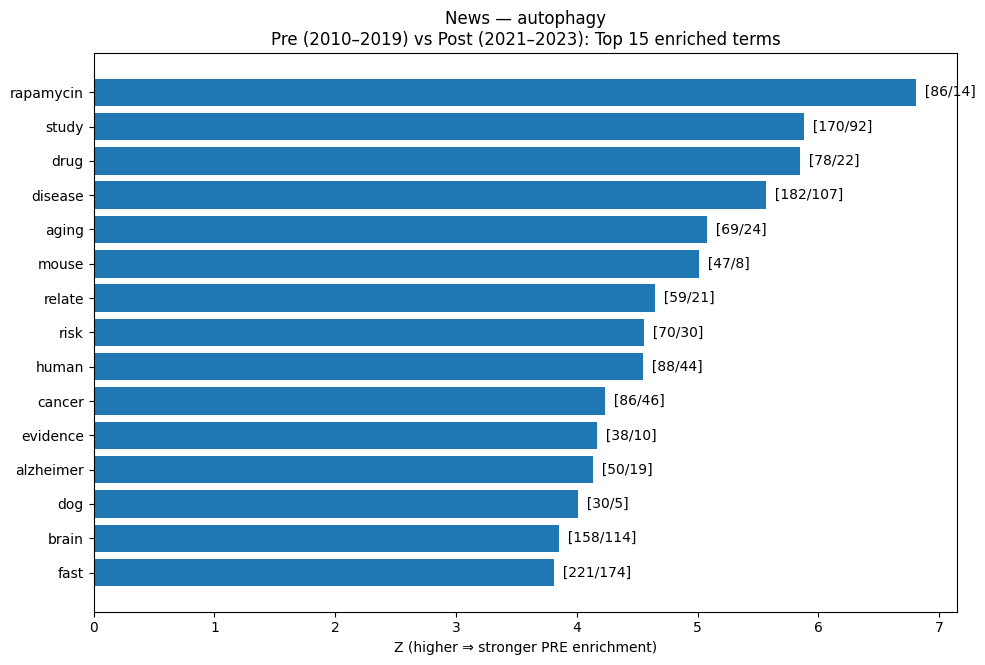

In [ ]:
plot_logodds_bars("News", 12, results=None, top_k=15, score_col="z")

Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/plots/logodds_reddit_exercise_fitness_post_gt_pre.png


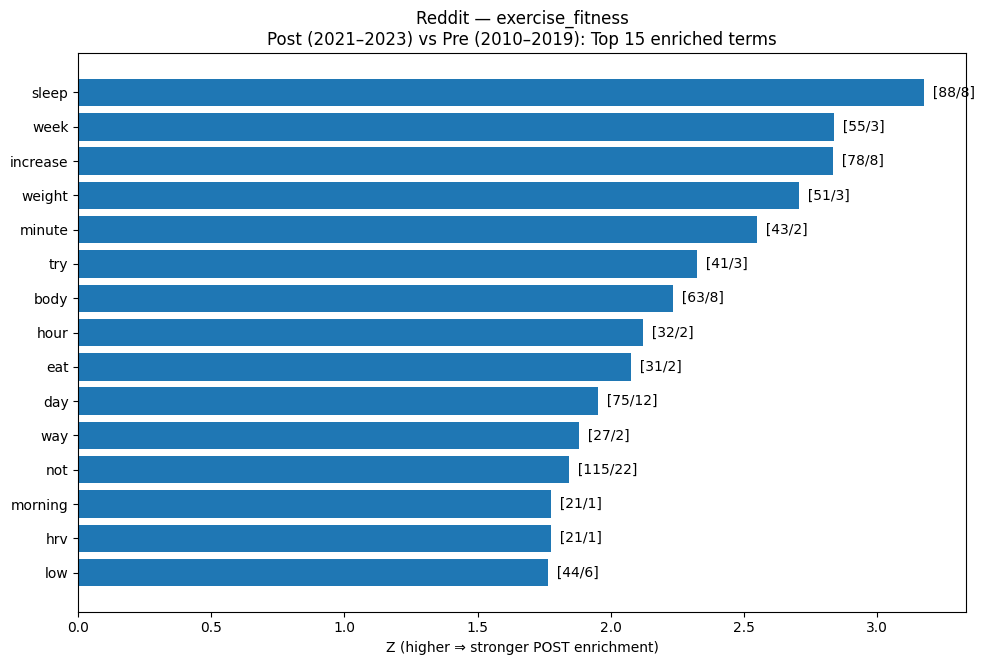

Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/plots/logodds_reddit_exercise_fitness_pre_gt_post.png


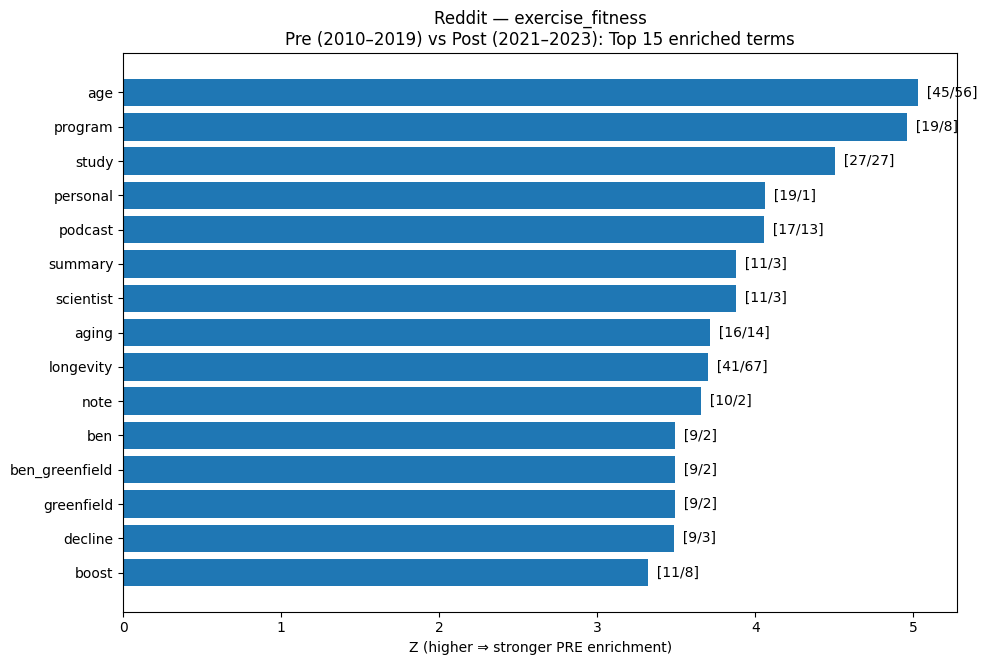

In [ ]:
plot_logodds_bars("Reddit", 6, results=None, top_k=15, score_col="z")

Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/plots/logodds_youtube_Telomere_post_gt_pre.png


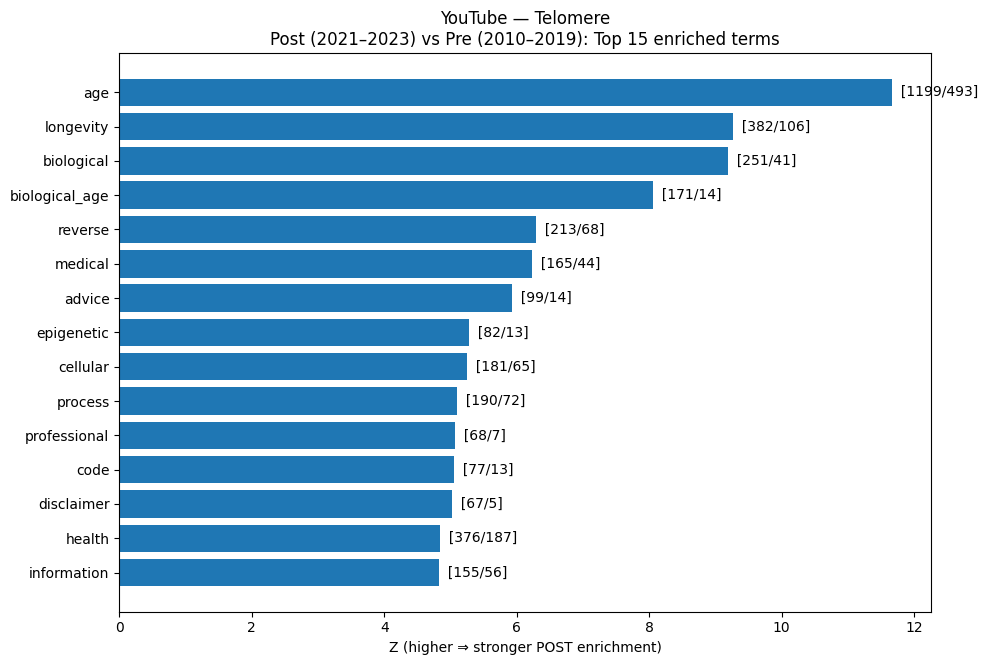

Saved → //content/drive/MyDrive/Keyword-analysis/rq3/out/narrative_shift/plots/logodds_youtube_Telomere_pre_gt_post.png


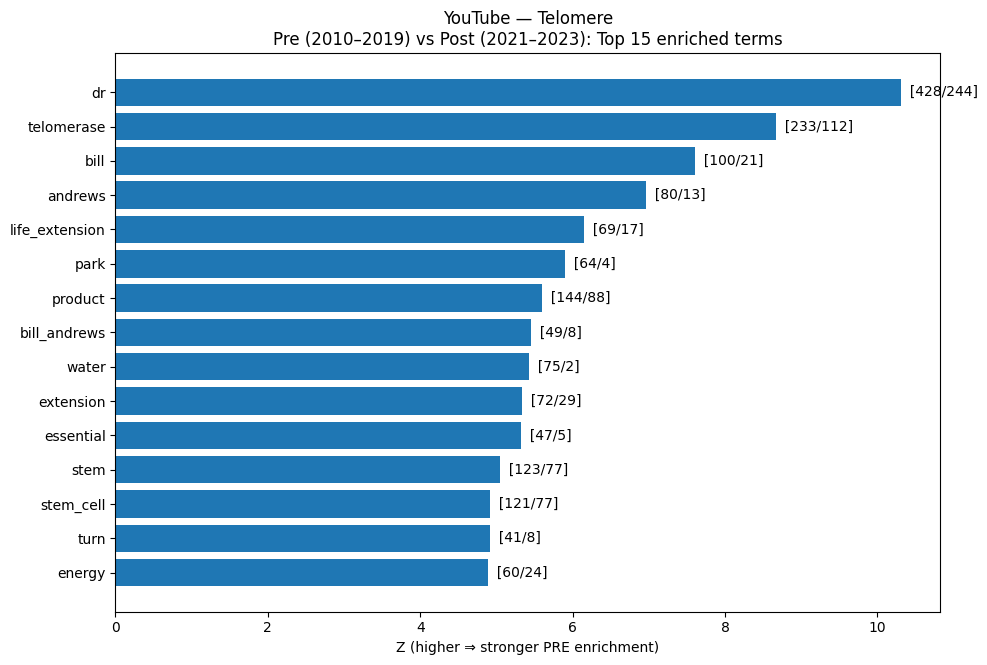

In [ ]:
plot_logodds_bars("YouTube", 2, results=None, top_k=15, score_col="z")

## Sentiment analysis

In [ ]:
# we have used already calculated sentiment scores
import pandas as pd

df = pd.read_csv(f"{path}/sentiment/topic_platform_yearly_sentiment_canonical.csv")

In [ ]:
print(df.shape)
print(df.isnull().sum())

(1088, 4)
topic        0
platform     0
year         0
sentiment    0
dtype: int64


In [ ]:
df.groupby('platform').size()

,0
platform,
News,272
PubMed,272
Reddit,272
YouTube,272


In [ ]:
  df.groupby('topic').size()

,0
topic,
['autophagy'],64
"['blood sugar', 'diabete', 'blood glucose']",64
['cancer'],64
['cardiovascular disease'],64
"['centenarian', 'supercentenarian', 'superager', 'super-ager']",64
"['dementia', 'alzheimer', 'cognitive decline', 'brain health']",64
"['epigenetic', 'methylation']",64
"['gut microbiome', 'gut microbiota', 'gut bacteria', 'gut health']",64
['metformin'],64


In [ ]:
print(df.isnull().sum())
df.head()

topic        0
platform     0
year         0
sentiment    0
dtype: int64


,topic,platform,year,sentiment
0,['autophagy'],News,2010,0.784027
1,['autophagy'],News,2011,-0.337052
2,['autophagy'],News,2012,0.173366
3,['autophagy'],News,2013,0.131626
4,['autophagy'],News,2014,0.243527


In [ ]:
import ast
import re

# (keywords) → canonical label
rules = [
    (["autophagy"],                           "autophagy"),
    (["blood sugar","diabete","blood glucose"], "diabetes_blood_sugar"),
    (["cancer"],                              "cancer"),
    (["cardiovascular disease"],              "cardiovascular_disease"),
    (["centenarian","supercentenarian","superager","super-ager"], "Centenarians"),
    (["dementia","alzheim","cognitive decline","brain health"],   "dementia_alzheimer"),
    (["epigenetic","methylation"],            "epigenetic_methylation"),
    (["gut microbiome","gut microbiota","gut bacteria","gut health"], "gut_microbiome"),
    (["metformin"],                           "metformin"),
    (["mitochondria","mitophagy"],            "mitochondria_mitophagy"),
    (["modafinil","nootropic"],               "modafinil_nootropic"),
    (["obesity"],                             "obesity"),
    (["rapamycin","sirolimus"],               "Rapamycin"),
    (["senescent cell","senolytic"],          "Senescent_cells"),
    (["sirtuins","sirt1","sirt3"],            "sirtuins"),
    (["strength training","exercise","fitness","physical activity","sedentary","walking","muscle mass"], "exercise_fitness"),
    (["telomere","telomerase"],               "Telomere"),
]

def normalize_topic_cell(x: str) -> str:
    # parse "['a','b']" → ['a','b'] ; if it fails, make a 1-item list
    try:
        items = ast.literal_eval(x)
        if not isinstance(items, (list, tuple)):
            items = [str(items)]
    except Exception:
        items = [str(x)]
    items = [s.lower() for s in items]

    txt = " ".join(items)  # join for substring checks
    for keywords, label in rules:
        for kw in keywords:
            # substring match (case-insensitive)
            if re.search(r"\b" + re.escape(kw.lower()) + r"\b", txt):
                return label
    # fallback: keep the first token or the raw string
    return items[0]

# apply
df["topic"] = df["topic"].astype(str).apply(normalize_topic_cell)

In [ ]:
df.groupby('topic').size()

,0
topic,
Centenarians,64
Rapamycin,64
Senescent_cells,64
Telomere,64
autophagy,64
cancer,64
cardiovascular_disease,64
dementia_alzheimer,64
diabetes_blood_sugar,64


#### Code explanation
##### 1. Overview & Purpose

This function generates grouped bar charts to visually compare the average sentiment of a specific topic before and after the pandemic across multiple platforms. By default, it completely excludes the noisy "shock year" of 2020, comparing the historical baseline (2010–2019) directly against the "new normal" (2021–2025).

---

##### 2. Data Processing & Statistics

- **`bar_pre_post_sentiment(...)`**

The function isolates the data for a single topic_label and computes standard summary statistics for the defined pre_years and post_years.

- **Mean Sentiment:**  
  Averages the yearly sentiment scores for the defined periods.  

- **Confidence Intervals:**  
  Calculates a simple 95% Confidence Interval (CI) using the standard error ($1.96 \times SE$) to represent the year-to-year variability within each window.  

- **Handling Sparsity:**  
  Includes failsafes to gracefully handle missing data, returning zeroes or NaN if a platform doesn't have enough data points for a given period.  

---

##### 3. Visualization Features

- **Grouped Bars:**  
  Plots the "Pre" and "Post" means side-by-side for each platform, allowing for an instant visual comparison of shifts in tone.  

- **Error Bars:**  
  Automatically overlays the calculated 95% CI on each bar (toggleable via `show_ci`) to indicate the statistical reliability of the mean  

- **Zero-Line:**  
  Includes a dashed horizontal line at 0 to quickly anchor the viewer on whether the overall sentiment is structurally positive or negative  

- **Sample Size Annotations:**  
  Prints the $n$ count (number of yearly observations) at the bottom of each bar, making it transparent if a bar is based on a full decade of data or just a few sparse years  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def bar_pre_post_sentiment(df,
                           topic_label,
                           platforms=None,
                           pre_years=range(2010, 2020),     # 2010–2019
                           post_years=range(2021, 2026),    # 2021–2023
                           show_ci=True,
                           figsize=(10,5),
                           title=None,
                           savepath=None):
    """
    Grouped bars (per platform): mean sentiment in PRE vs POST windows for a given topic.
    PRE excludes 2020 by default. POST uses 2021–2023.
    Error bars: 95% CI from year-to-year variability within each window.
    """
    d = df.copy()
    d["year"] = pd.to_numeric(d["year"], errors="coerce").astype("Int64")

    # filter to chosen topic
    d = d[d["topic"] == topic_label].copy()
    if d.empty:
        print(f"No rows for topic='{topic_label}'.")
        return

    # restrict platforms if provided
    if platforms is not None:
        d = d[d["platform"].isin(platforms)].copy()

    # aggregate per platform & window
    rows = []
    for plat, g in d.groupby("platform"):
        pre_vals  = g[g["year"].isin(pre_years)]["sentiment"].dropna().values
        post_vals = g[g["year"].isin(post_years)]["sentiment"].dropna().values

        def stats(arr):
            if len(arr) == 0:
                return np.nan, np.nan, 0, np.nan
            m = float(np.mean(arr))
            sd = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
            n = int(len(arr))
            se = sd / np.sqrt(n) if n > 0 else np.nan
            ci = 1.96 * se if n > 1 else 0.0   # simple 95% CI
            return m, ci, n, sd

        pre_mean, pre_ci, pre_n, _   = stats(pre_vals)
        post_mean, post_ci, post_n, _ = stats(post_vals)

        rows.append({
            "platform": plat,
            "pre_mean": pre_mean, "pre_ci": pre_ci, "pre_n": pre_n,
            "post_mean": post_mean, "post_ci": post_ci, "post_n": post_n
        })

    summ = pd.DataFrame(rows).sort_values("platform")
    if summ.empty:
        print("Nothing to plot after filtering.")
        return

    # plotting
    x = np.arange(len(summ))
    width = 0.36

    plt.figure(figsize=figsize)

    # bars
    b1 = plt.bar(x - width/2, summ["pre_mean"], width, label=f"Pre ({min(pre_years)}–{max(pre_years)})")
    b2 = plt.bar(x + width/2, summ["post_mean"], width, label=f"Post ({min(post_years)}–{max(post_years)})")

    # error bars (optional)
    if show_ci:
        plt.errorbar(x - width/2, summ["pre_mean"], yerr=summ["pre_ci"], fmt="none", capsize=3)
        plt.errorbar(x + width/2, summ["post_mean"], yerr=summ["post_ci"], fmt="none", capsize=3)

    # zero line
    plt.axhline(0, color="k", linestyle="--", linewidth=1, alpha=0.4)

    # x labels
    plt.xticks(x, summ["platform"].tolist())
    plt.ylabel("Mean (length-weighted) sentiment")
    plt.xlabel("Platform")
    plt.title(title or f"Pre vs Post Sentiment — Topic: {topic_label}")
    plt.legend(loc="best")
    plt.grid(axis="y", alpha=0.25)

    # annotate n (years) under each pair
    for i, r in summ.iterrows():
        plt.text(x[i] - width/2, plt.gca().get_ylim()[0]*0.98, f"n={int(r['pre_n'])}", ha="center", va="top", fontsize=8, rotation=0)
        plt.text(x[i] + width/2, plt.gca().get_ylim()[0]*0.98, f"n={int(r['post_n'])}", ha="center", va="top", fontsize=8, rotation=0)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200)
        print(f"Saved → {savepath}")
    plt.show()


Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/sentiment/Modafinil_nootropic


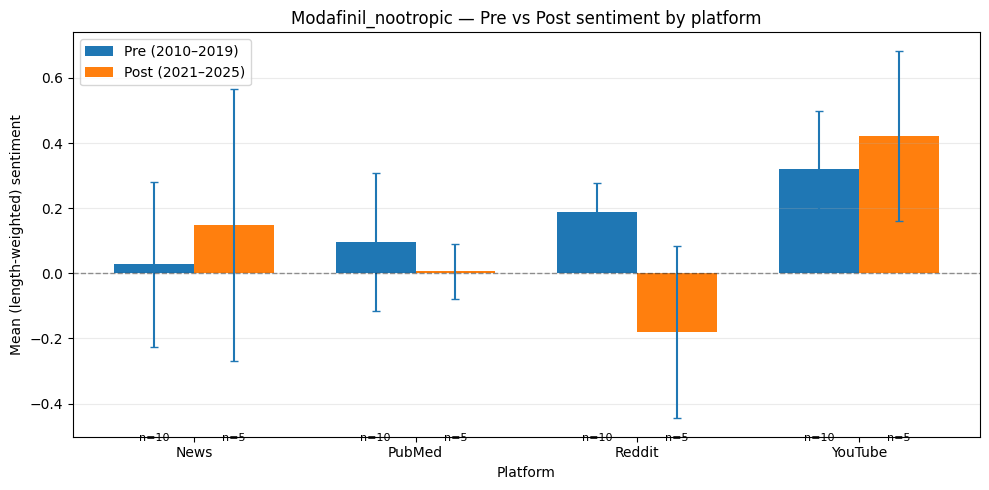

In [ ]:
# Example for one topic across all platforms present in df:
bar_pre_post_sentiment(df, topic_label="modafinil_nootropic",
                       pre_years=range(2010,2020),
                       post_years=range(2021,2026),
                       show_ci=True,
                       title="Modafinil_nootropic — Pre vs Post sentiment by platform",
                       savepath=f"{path}/sentiment/Modafinil_nootropic")

# Or restrict to specific platforms:
# bar_pre_post_sentiment(df, "modafinil_nootropic", platforms=["Reddit","News","PubMed"])

Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/sentiment/Autophagy


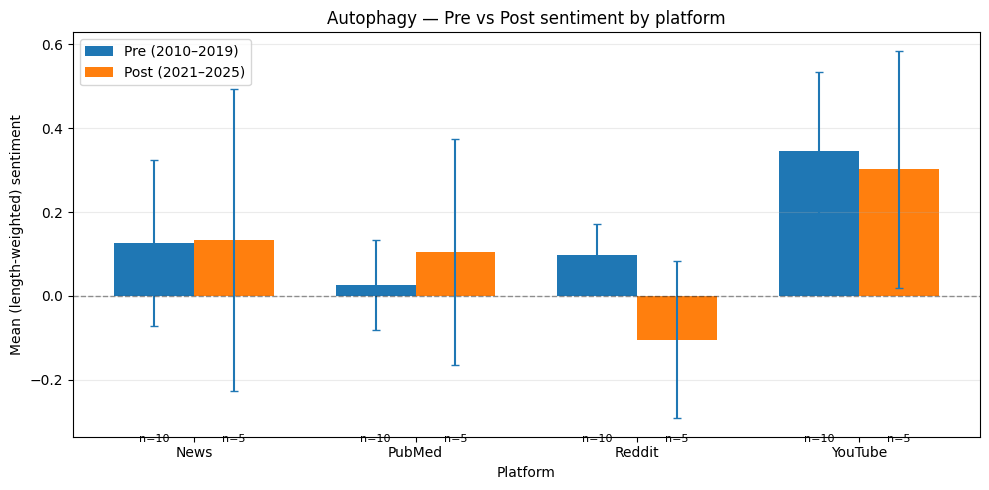

In [ ]:
# Example for one topic across all platforms present in df:
bar_pre_post_sentiment(df, topic_label="autophagy",
                       pre_years=range(2010,2020),
                       post_years=range(2021,2026),
                       show_ci=True,
                       title="Autophagy — Pre vs Post sentiment by platform",
                       savepath=f"{path}/sentiment/Autophagy")

# Or restrict to specific platforms:
# bar_pre_post_sentiment(df, "modafinil_nootropic", platforms=["Reddit","News","PubMed"])

Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/sentiment/fitness


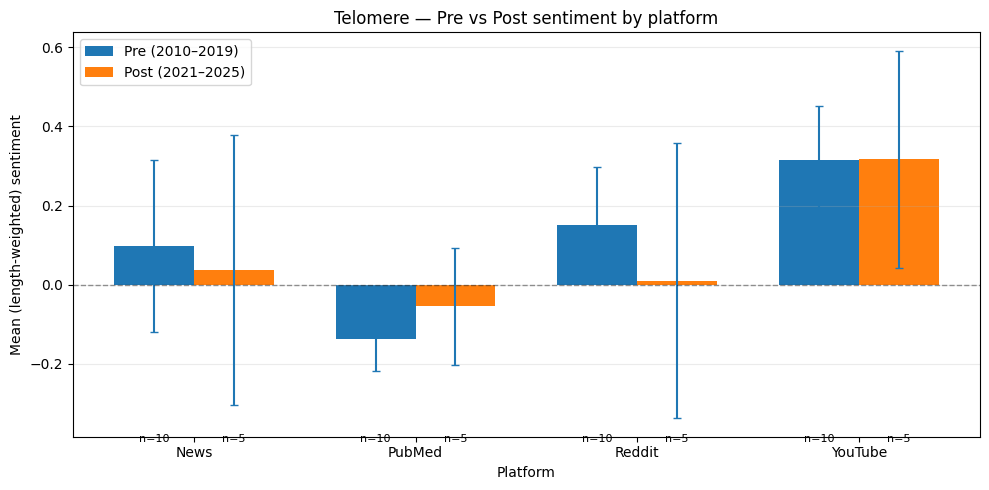

In [ ]:
# Example for one topic across all platforms present in df:
bar_pre_post_sentiment(df, topic_label="Telomere",
                       pre_years=range(2010,2020),
                       post_years=range(2021,2026),
                       show_ci=True,
                       title="Telomere — Pre vs Post sentiment by platform",
                       savepath=f"{path}/sentiment/fitness")

# Or restrict to specific platforms:
# bar_pre_post_sentiment(df, "modafinil_nootropic", platforms=["Reddit","News","PubMed"])

Saved → /content/drive/MyDrive/Keyword-analysis/rq3/out/sentiment/dementia


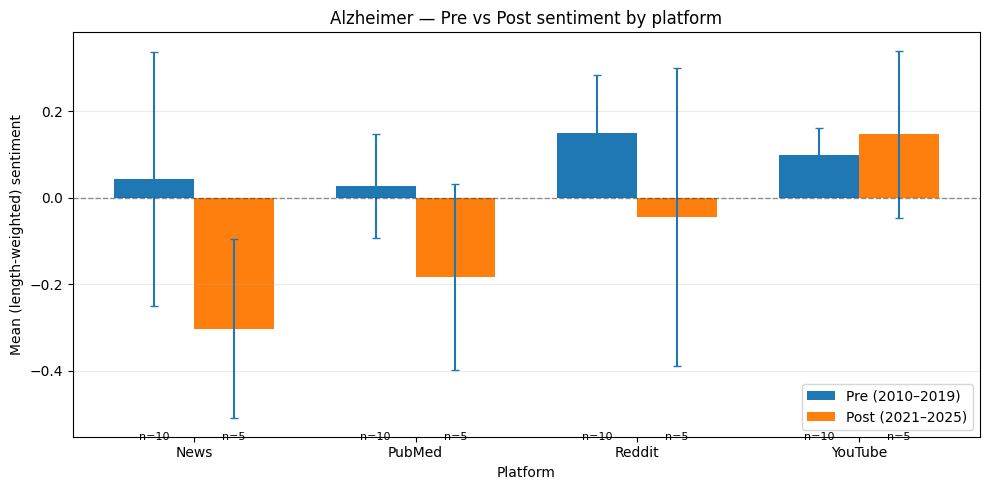

In [ ]:
# Example for one topic across all platforms present in df:
bar_pre_post_sentiment(df, topic_label="dementia_alzheimer",
                       pre_years=range(2010,2020),
                       post_years=range(2021,2026),
                       show_ci=True,
                       title="Alzheimer — Pre vs Post sentiment by platform",
                       savepath=f"{path}/sentiment/dementia")

# Or restrict to specific platforms:
# bar_pre_post_sentiment(df, "modafinil_nootropic", platforms=["Reddit","News","PubMed"])